In [2]:
from pathlib import Path
import os
import sys
import pickle

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
%matplotlib inline

from sklearn.metrics import accuracy_score, confusion_matrix

# OLD FORMAT

In [61]:
root_path = "/Users/kautsarg/Documents/Final Project/Run Data/trial test data/"
sample_name = "D20250808_E00_C00_F4500KHz_U_Sample_7"
exp_path = os.path.join(root_path, sample_name)
data_path = os.path.join(exp_path, "classification_performances_with_proba.pkl")
with open(data_path, 'rb') as f:
    result_data = pickle.load(f)

In [84]:
result_data

{'Avg Cleaned Lowest Fitted Stretched': {'Native': {None: {'y_trues_': [array([5, 1, 5, ..., 3, 9, 1])],
    'y_preds_AC_': [array([3, 1, 3, ..., 4, 9, 9])],
    'y_probs_AC_': [array([[7.7102780e-03, 9.1935791e-02, 3.3554409e-02, ..., 7.7320985e-03,
             1.6680710e-02, 4.1204933e-02],
            [8.2305588e-02, 3.0859703e-01, 1.9817923e-03, ..., 2.5674123e-02,
             1.4599539e-01, 9.1683134e-02],
            [1.8847477e-02, 2.7564061e-01, 5.6273951e-03, ..., 1.1097790e-02,
             8.1874179e-03, 1.9422959e-01],
            ...,
            [3.4182891e-03, 1.9155718e-02, 5.8676200e-03, ..., 3.0604204e-02,
             3.1743519e-05, 3.3317627e-03],
            [2.2553113e-01, 1.3277522e-01, 6.3092523e-04, ..., 9.1540897e-03,
             2.3104911e-01, 3.7312397e-01],
            [5.9841596e-02, 1.5606940e-01, 1.5175082e-03, ..., 4.7852700e-03,
             3.3895209e-02, 6.5413749e-01]], dtype=float32)],
    'classes_AC_': [array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])],


In [63]:
EXPECTED_CLASSES = list(range(10)) 
model_key_mapping = {
    "CNN": "y_preds_AC_",
    # "KNN": "y_preds_AC_kNN_",
    # "LR":  "y_preds_FFI_"
}

rows = []

print("[*] Flattening dictionary into tabular format...")
for curve_name, modes in result_data.items():
    for mode_name, filters in modes.items():

        total_samples = max(metrics.get("mask_count", 0) for metrics in filters.values())
        
        for filter_name, metrics in filters.items():
            clean_filter = filter_name if filter_name is not None else "Baseline_None"
            surviving_samples = metrics.get("mask_count", total_samples)
            outlier_pct = ((total_samples - surviving_samples) / total_samples) * 100
            
            y_true = np.concatenate(metrics["y_trues_"])
            
            for clean_model_name, dict_key in model_key_mapping.items():
                y_pred = np.concatenate(metrics[dict_key])
                
                total_acc = accuracy_score(y_true, y_pred)
                
                row_data = {
                    "curve_name": curve_name,
                    "training_mode": mode_name,
                    "outlier_filter": clean_filter,
                    "model": clean_model_name,
                    "outlier_percentage": round(outlier_pct, 2),  # Rounded for cleaner CSV reading
                    "total_accuracy": total_acc
                }
                
                cm = confusion_matrix(y_true, y_pred, labels=EXPECTED_CLASSES)
                
                with np.errstate(divide='ignore', invalid='ignore'):
                    per_class_acc = cm.diagonal() / cm.sum(axis=1)
                
                for well_idx in EXPECTED_CLASSES:
                    col_name = f"accuracy_well_{well_idx}"
                    row_data[col_name] = per_class_acc[well_idx]
                    
                rows.append(row_data)

result_df = pd.DataFrame(rows)

csv_out = os.path.join(exp_path, "flattened_results.csv")
result_df["accuracy_well_avg"] = np.average(result_df.filter(like="accuracy_well_"), axis=1)
result_df.to_csv(csv_out, index=False)
print(f"\n[*] Saved flat CSV to: {csv_out}")

[*] Flattening dictionary into tabular format...

[*] Saved flat CSV to: /Users/kautsarg/Documents/Final Project/Run Data/trial test data/D20250808_E00_C00_F4500KHz_U_Sample_7/flattened_results.csv


In [64]:
print("Curves:")
print(np.unique(result_df.curve_name))
print("-"*50)

print("Filter:")
print(np.unique(result_df.outlier_filter))
print("-"*50)

Curves:
['Avg Cleaned Lowest Fitted Full' 'Avg Cleaned Lowest Fitted Stretched'
 'Avg Cleaned Std Fitted Full' 'Avg Cleaned Std Fitted Stretched'
 'Avg Fitted Full' 'Avg Fitted Stretched' 'Cleaned Lowest Fitted Full'
 'Cleaned Lowest Fitted Stretched' 'Cleaned Std Fitted Full'
 'Cleaned Std Fitted Stretched' 'Ori Curves' 'Ori Curves Avg'
 'Original Fitted Full' 'Original Fitted Stretched']
--------------------------------------------------
Filter:
['Baseline_None' 'ae_well_label_90' 'ae_well_label_95'
 'ae_well_label_elbow' 'amf_label_amf_important' 'amf_label_amf_send_10'
 'amf_label_amf_send_15' 'amf_label_amf_send_20' 'amf_label_amf_send_25'
 'amf_label_amf_send_5' 'amf_label_amf_send_abs_10'
 'amf_label_amf_send_abs_15' 'amf_label_amf_send_abs_20'
 'amf_label_amf_send_abs_25' 'amf_label_amf_send_abs_5' 'cnn_ae_label_90'
 'cnn_ae_label_95' 'cnn_ae_label_elbow' 'knn_top_0.85' 'knn_top_0.9'
 'knn_top_0.95' 'mean_std_label_env_1std' 'mean_std_label_env_2std'
 'mean_std_label_env_3std' 

## OUTLIER DETECTION METHOD COMPARISON

In [65]:
def plot_accuracy_comparison_static(filtered_df, title="Model Accuracy Comparison", save_path=None):
    """
    Generates a static high-resolution grouped bar chart using Seaborn,
    with custom gridlines and 90-degree data labels inside the bars.
    """
    
    sns.set_theme(style="white", font_scale=1.1) 
    fig, ax = plt.subplots(figsize=(12, 7)) 
    
    barplot = sns.barplot(
        data=filtered_df, 
        x="model", 
        y="total_accuracy", 
        hue="curve_name",
        palette="viridis",
        edgecolor="black",
        linewidth=1,
        ax=ax
    )
    
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel("Machine Learning Model", fontsize=14, fontweight='bold')
    ax.set_ylabel("Total Accuracy", fontsize=14, fontweight='bold')
    
    # --- 1. SET Y-AXIS EXACTLY 0 to 100% ---
    ax.set_ylim(0, 1.0)
    
    # Set gridlines (Major every 5%, Minor every 1%)
    ax.yaxis.set_major_locator(mtick.MultipleLocator(0.05))
    ax.yaxis.set_minor_locator(mtick.MultipleLocator(0.01))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
    
    ax.grid(which='major', axis='y', linestyle='-', linewidth=1.5, color='#eaeaea')
    ax.grid(which='minor', axis='y', linestyle=':', linewidth=1, color='#cccccc', alpha=0.7)
    ax.set_axisbelow(True) 
    
    # --- 2. ADD ACCURACY TEXT INSIDE THE BARS (ROTATED 90 DEG) ---
    for container in ax.containers:
        labels = [f"{bar.get_height()*100:.1f}%" if bar.get_height() > 0 else "" for bar in container]
        
        ax.bar_label(
            container, 
            labels=labels, 
            label_type='edge',     # Anchor to the top edge of the bar
            padding=-35,           # Negative padding pulls the text DOWN inside the bar
            fontsize=10, 
            fontweight='bold', 
            color='white',         # White text pops best inside colored bars
            rotation=90            # Rotate 90 degrees pointing up
        )
    
    # Move legend outside
    plt.legend(title='Curve Type', bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=300, facecolor='white')
        print(f"[*] Saved static plot to {save_path}")

def plot_flexible_grouped_bar(df, x_col, y_col, hue_col, title=None, is_percentage=True, is_horizontal=False, baseline_value=None, save_path=None):
    """
    A highly flexible grouped bar chart generator using Seaborn.
    Supports vertical/horizontal orientations and dynamic baseline thresholds.
    """
    
    sns.set_theme(style="white", font_scale=1.1) 
    
    # 1. Map Data Based on Orientation
    if is_horizontal:
        fig, ax = plt.subplots(figsize=(12, 12)) 
        sns.barplot(data=df, x=y_col, y=x_col, hue=hue_col, palette="viridis", edgecolor="black", linewidth=1, ax=ax)
        ax.set_xlabel(y_col.replace("_", " ").title(), fontsize=14, fontweight='bold')
        ax.set_ylabel(x_col.replace("_", " ").title(), fontsize=14, fontweight='bold')
        ax.tick_params(axis='y', rotation=0) 
    else:
        fig, ax = plt.subplots(figsize=(12, 7)) 
        sns.barplot(data=df, x=x_col, y=y_col, hue=hue_col, palette="viridis", edgecolor="black", linewidth=1, ax=ax)
        ax.set_xlabel(x_col.replace("_", " ").title(), fontsize=14, fontweight='bold')
        ax.set_ylabel(y_col.replace("_", " ").title(), fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=90)
    
    if title:
        ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
        
    # 2. Dynamic Axis & Grid Formatting
    val_axis = ax.xaxis if is_horizontal else ax.yaxis
    grid_axis = 'x' if is_horizontal else 'y'
    
    if is_percentage:
        if is_horizontal: ax.set_xlim(0, 1.0)
        else: ax.set_ylim(0, 1.0)
            
        val_axis.set_major_locator(mtick.MultipleLocator(0.1))
        val_axis.set_minor_locator(mtick.MultipleLocator(0.01))
        val_axis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
        
        ax.grid(which='major', axis=grid_axis, linestyle='-', linewidth=1.5, color='#eaeaea')
        ax.grid(which='minor', axis=grid_axis, linestyle=':', linewidth=1, color='#cccccc', alpha=0.7)
    else:
        ax.grid(which='major', axis=grid_axis, linestyle='-', linewidth=1.5, color='#eaeaea')
        
    ax.set_axisbelow(True) 
    
    # --- NEW: Draw Baseline Threshold ---
    if baseline_value is not None:
        if is_horizontal:
            # Draw vertical line if bars are horizontal
            ax.axvline(x=baseline_value, color='#e74c3c', linestyle='--', linewidth=2.5, zorder=5)
        else:
            # Draw horizontal line if bars are vertical
            ax.axhline(y=baseline_value, color='#e74c3c', linestyle='--', linewidth=2.5, zorder=5)
    
    # 3. Dynamic Bar Annotations (Text)
    for container in ax.containers:
        labels = []
        for bar in container:
            val = bar.get_width() if is_horizontal else bar.get_height()
            
            if val > 0:
                labels.append(f"{val*100:.1f}%" if is_percentage else f"{val:.2f}")
            else:
                labels.append("")
        
        text_padding = -35 if is_percentage else 5
        text_color = 'white' if is_percentage else '#333333'
        text_rotation = 0 if is_horizontal else 90
            
        ax.bar_label(
            container, 
            labels=labels, 
            label_type='edge',     
            padding=text_padding,          
            fontsize=10, 
            fontweight='bold', 
            color=text_color,         
            rotation=text_rotation            
        )
    
    # 4. Legend & Layout
    legend_title = hue_col.replace("_", " ").title()
    plt.legend(title=legend_title, bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=300, facecolor='white')
        print(f"[*] Saved static plot to {save_path}")

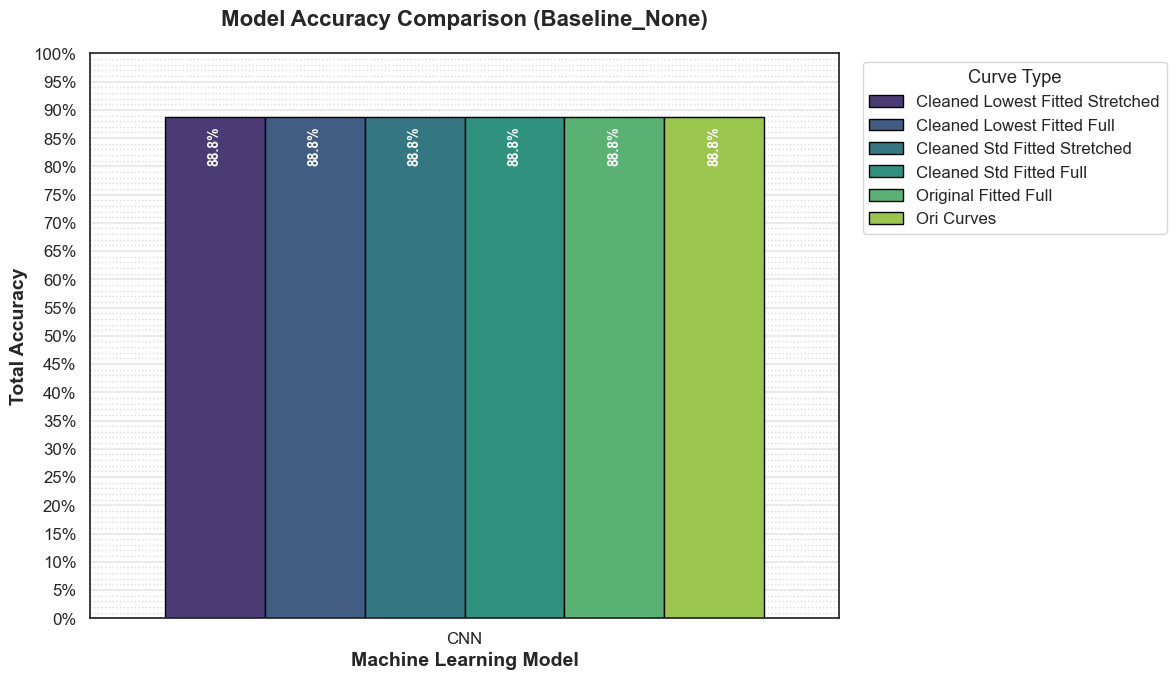

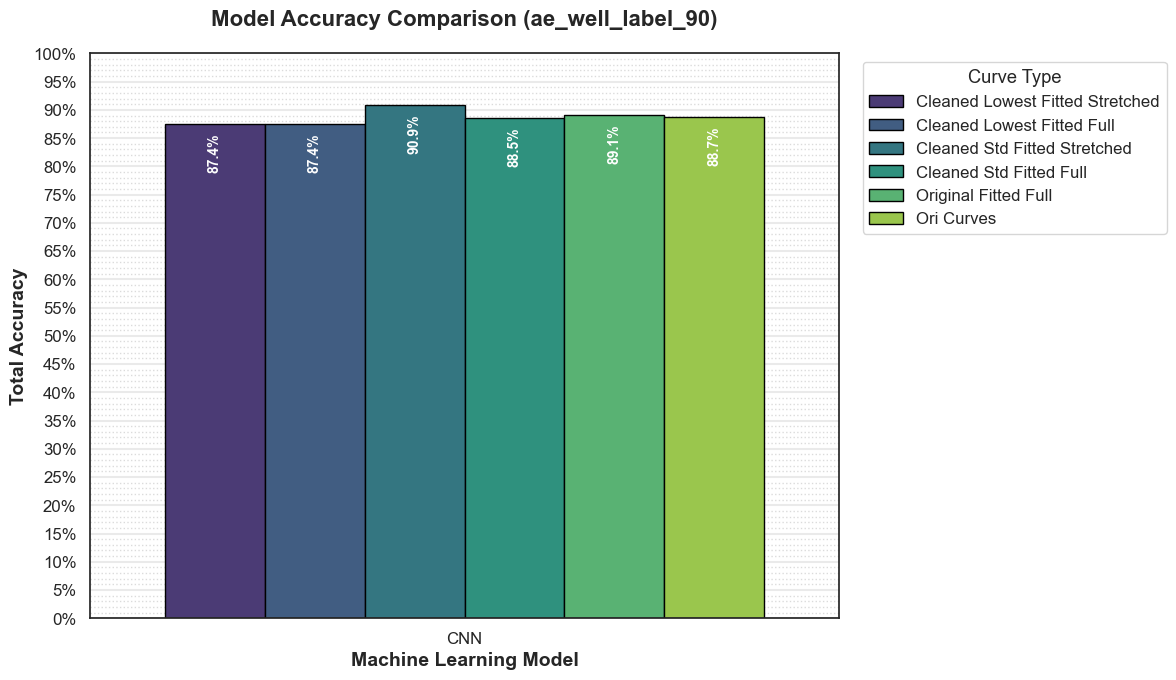

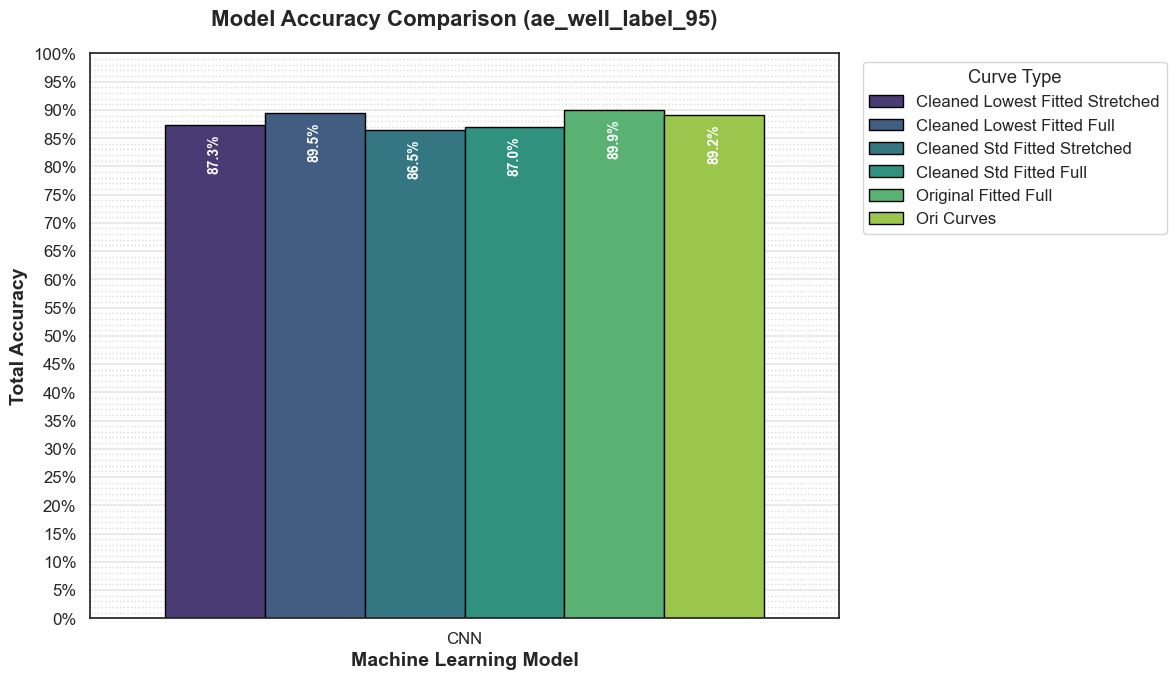

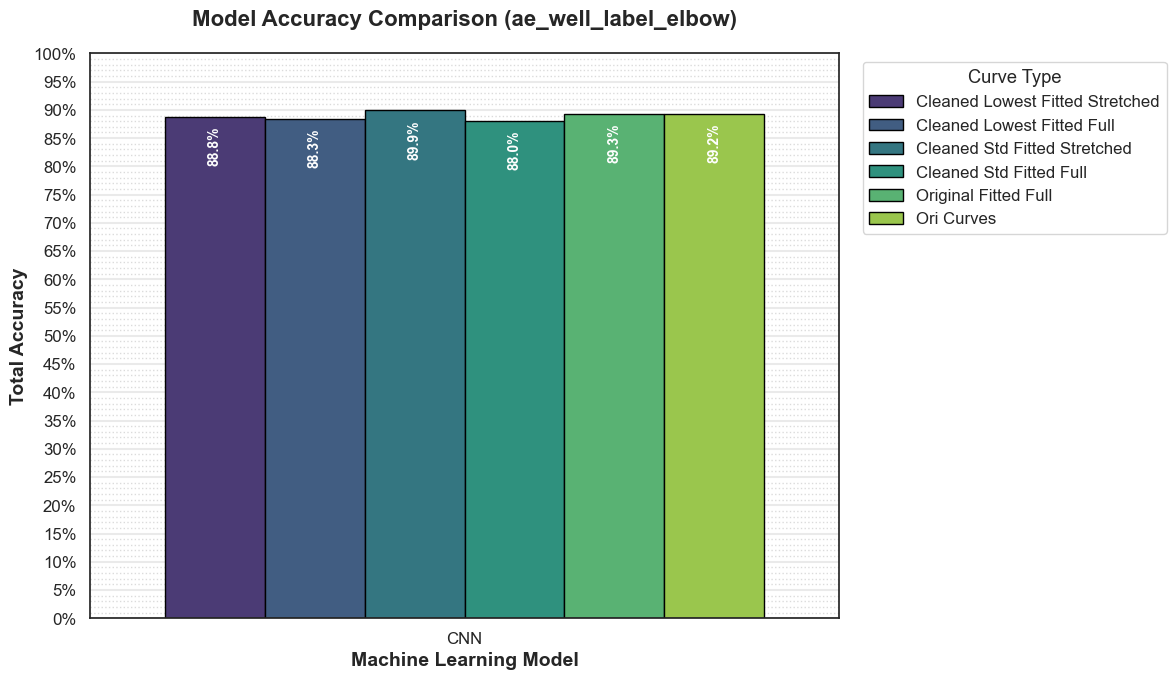

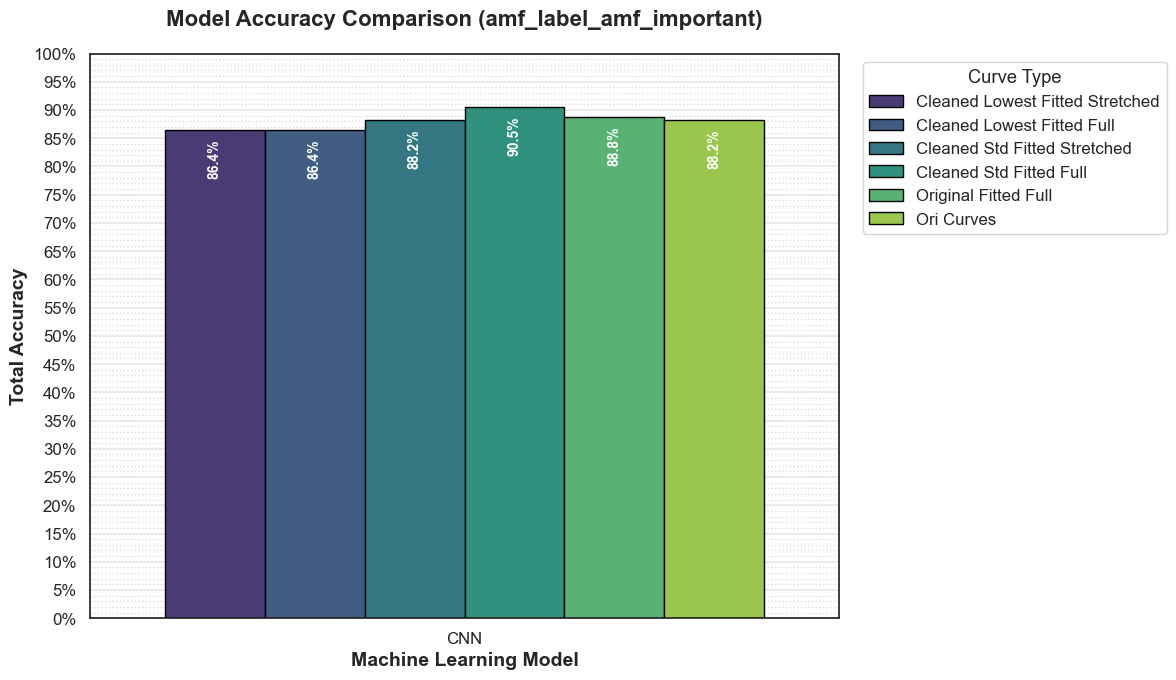

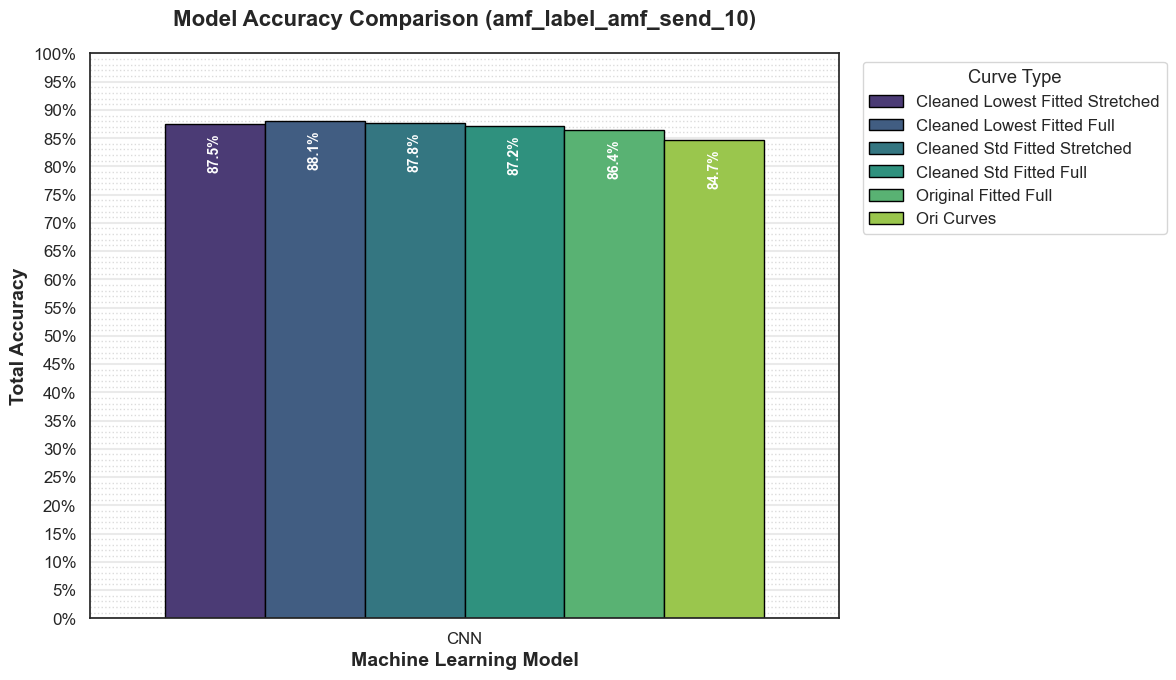

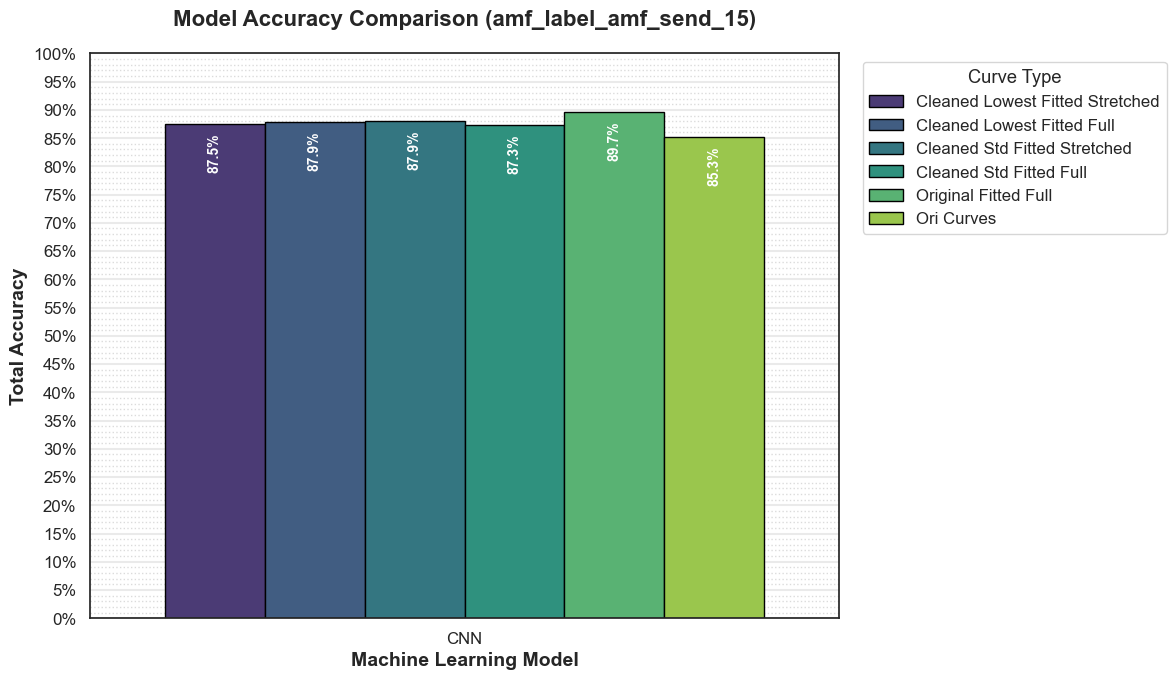

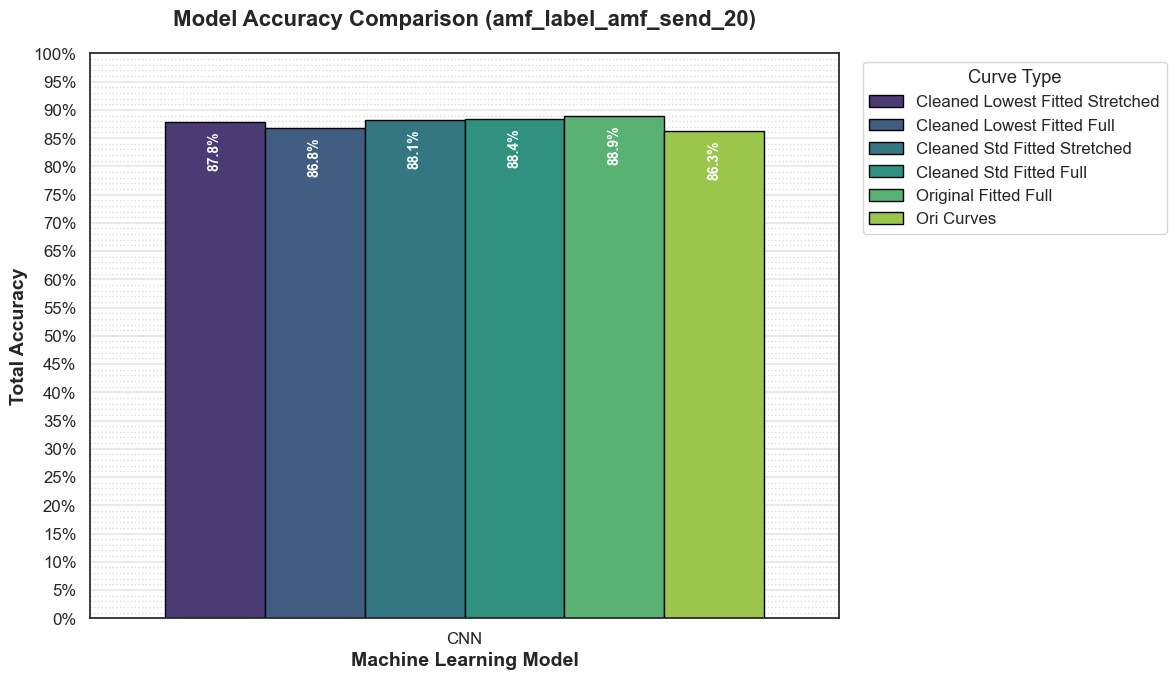

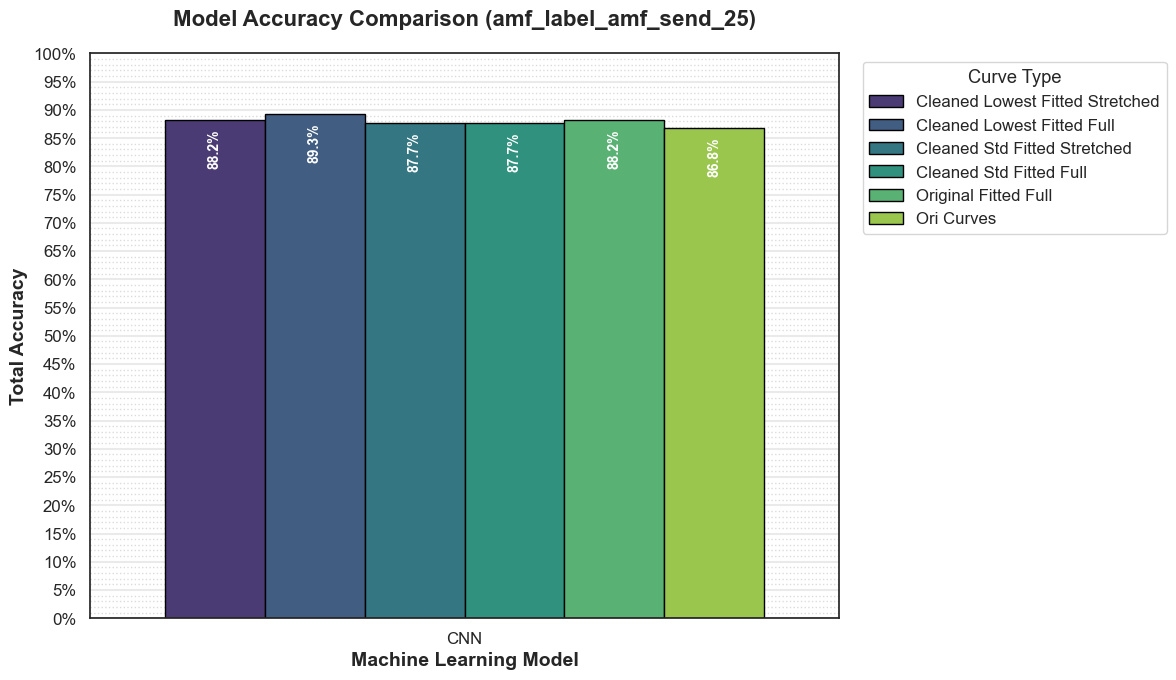

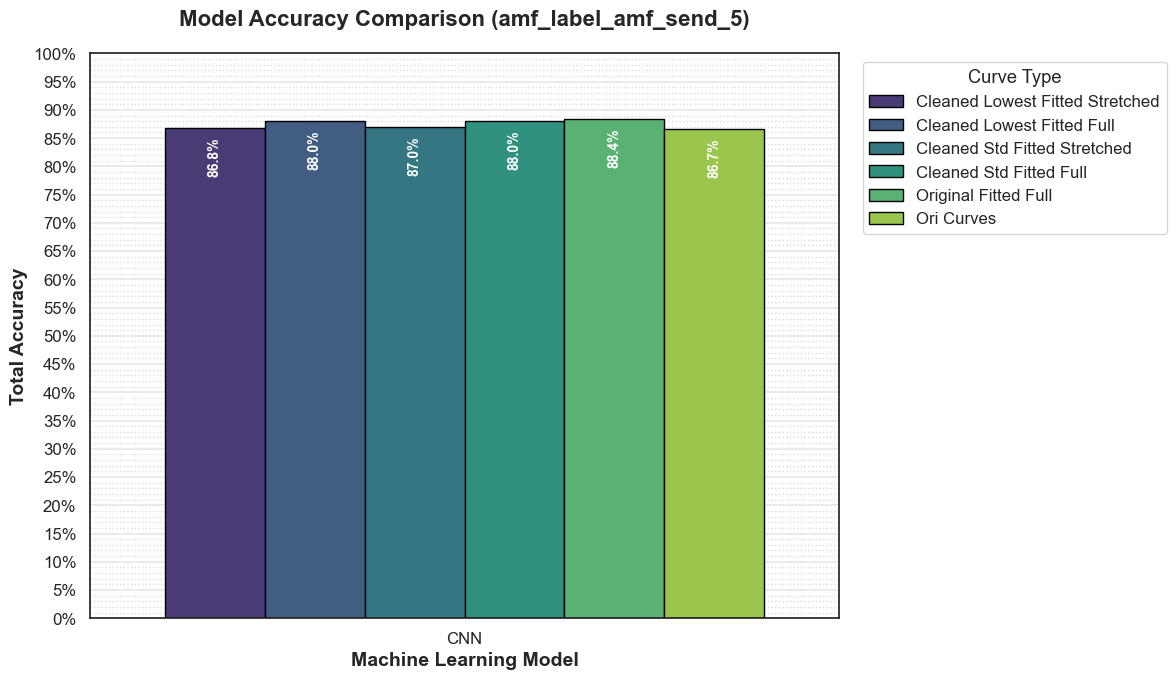

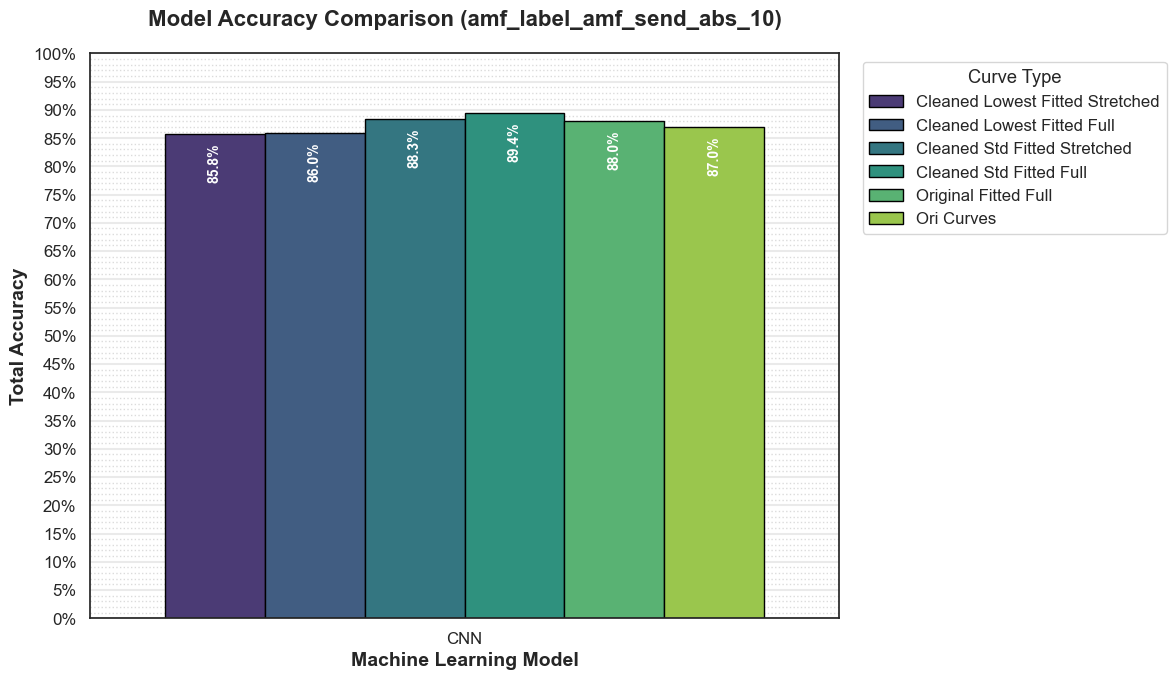

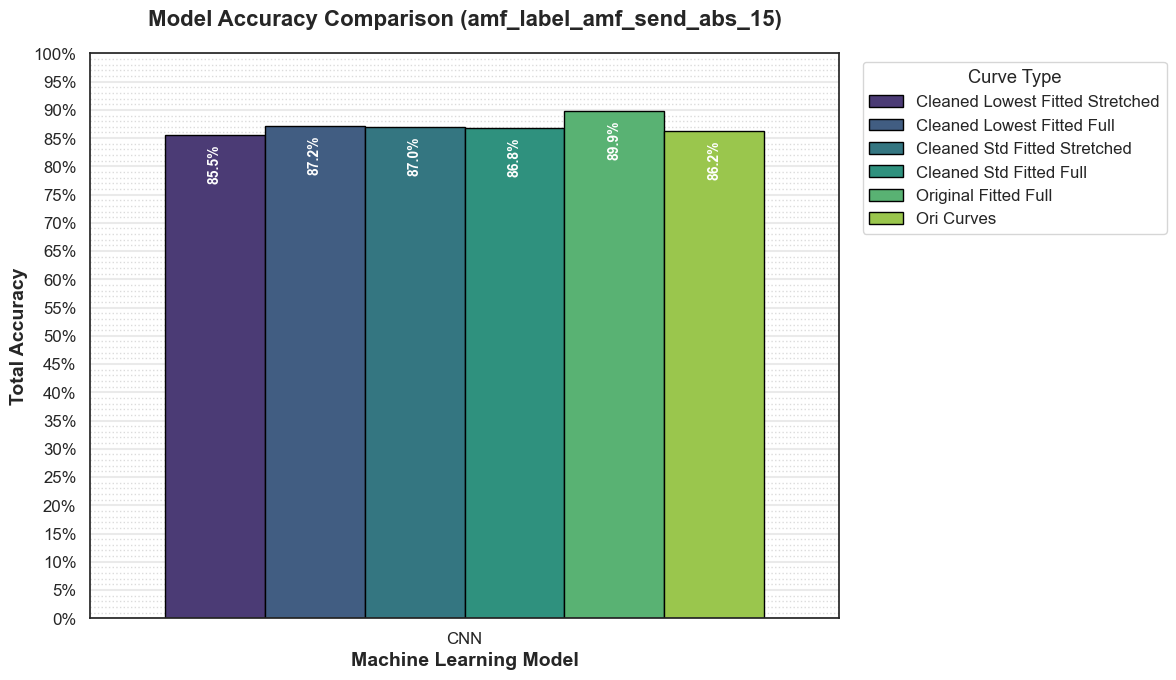

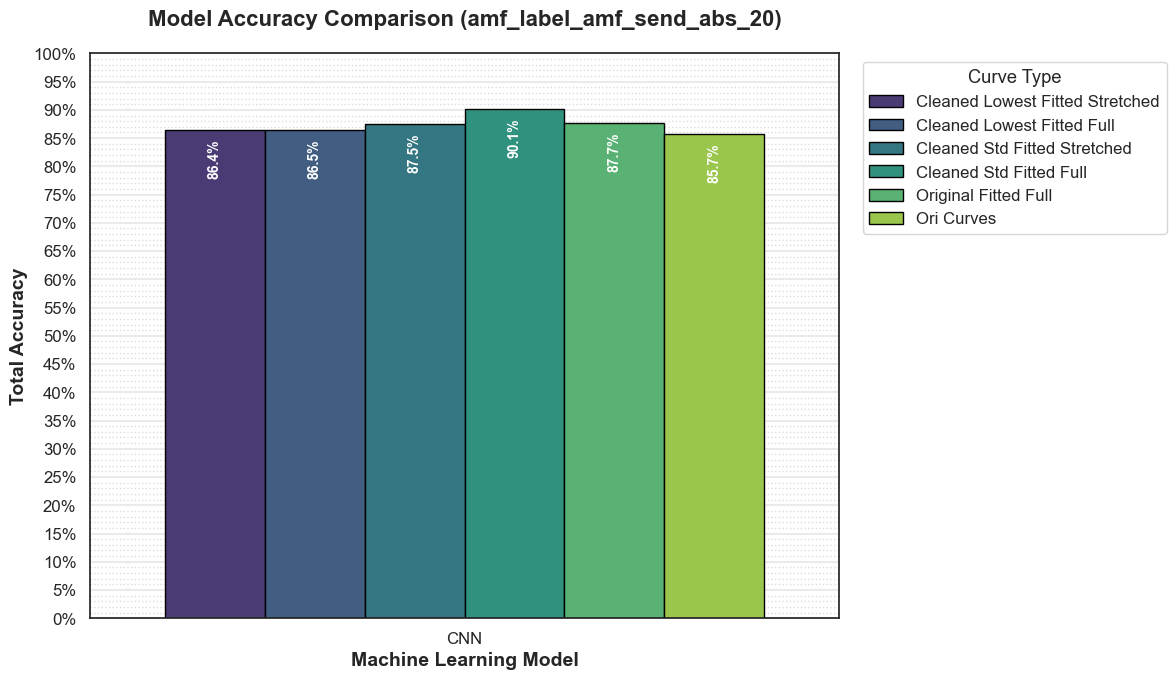

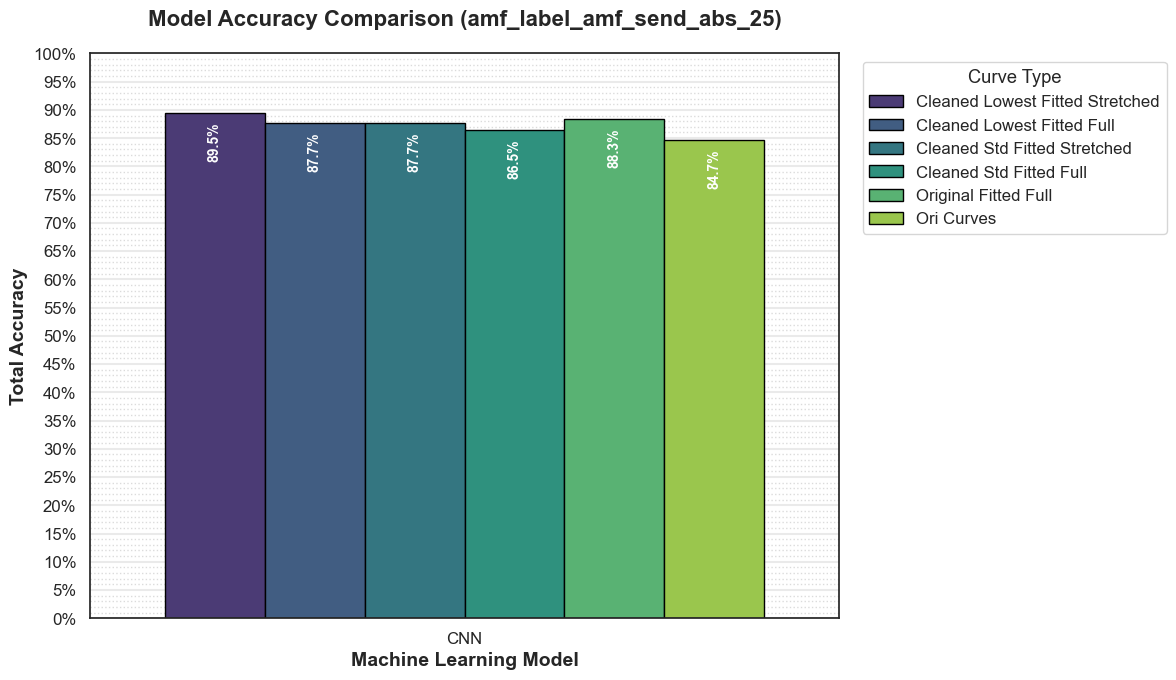

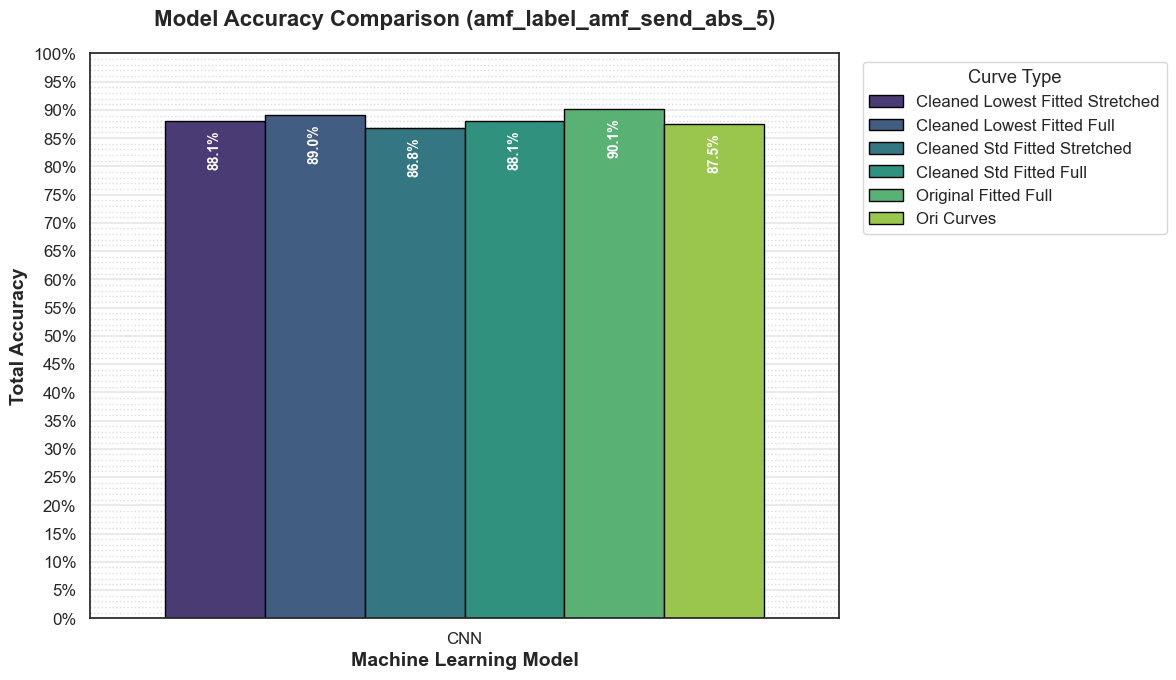

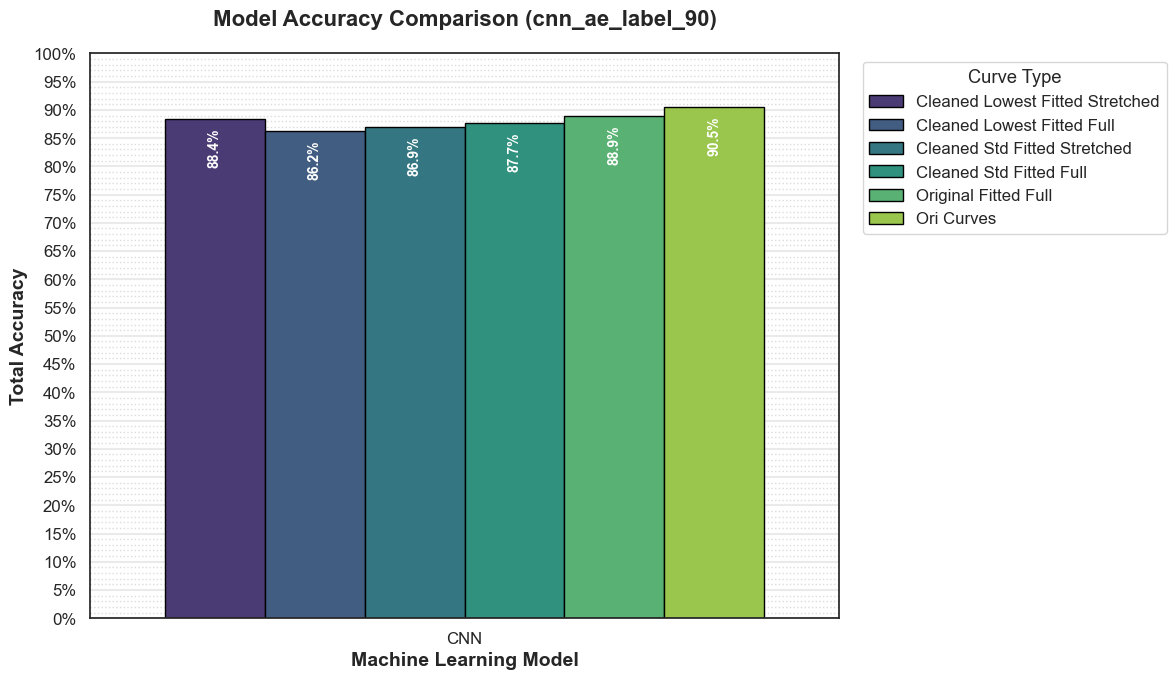

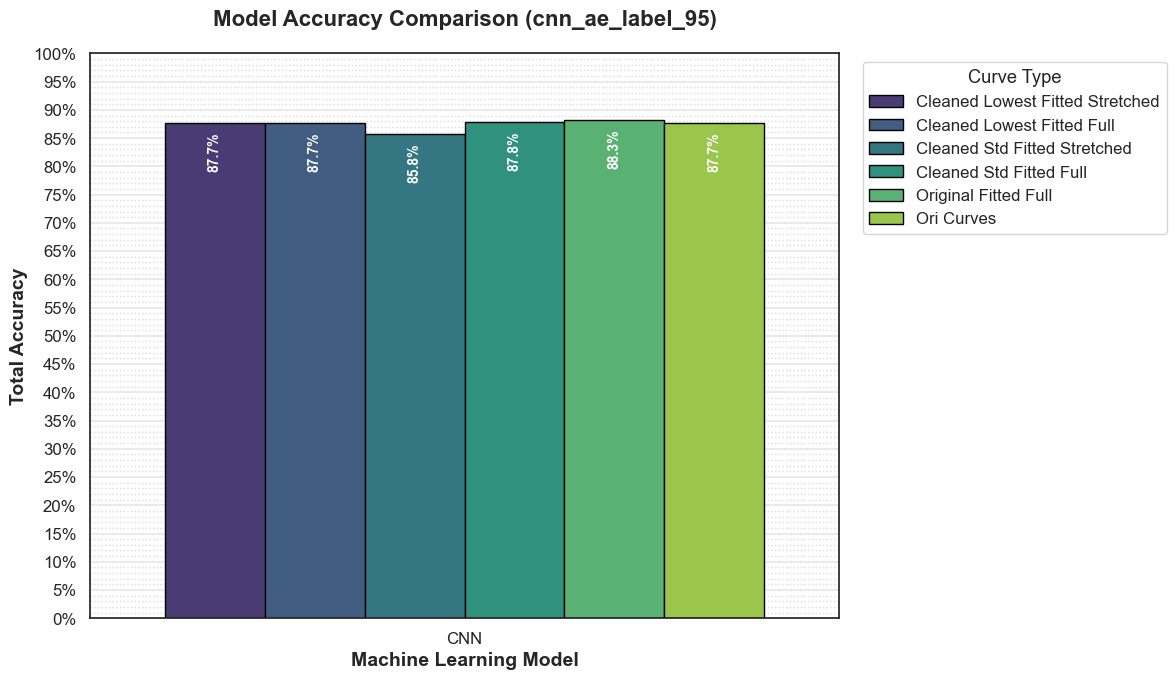

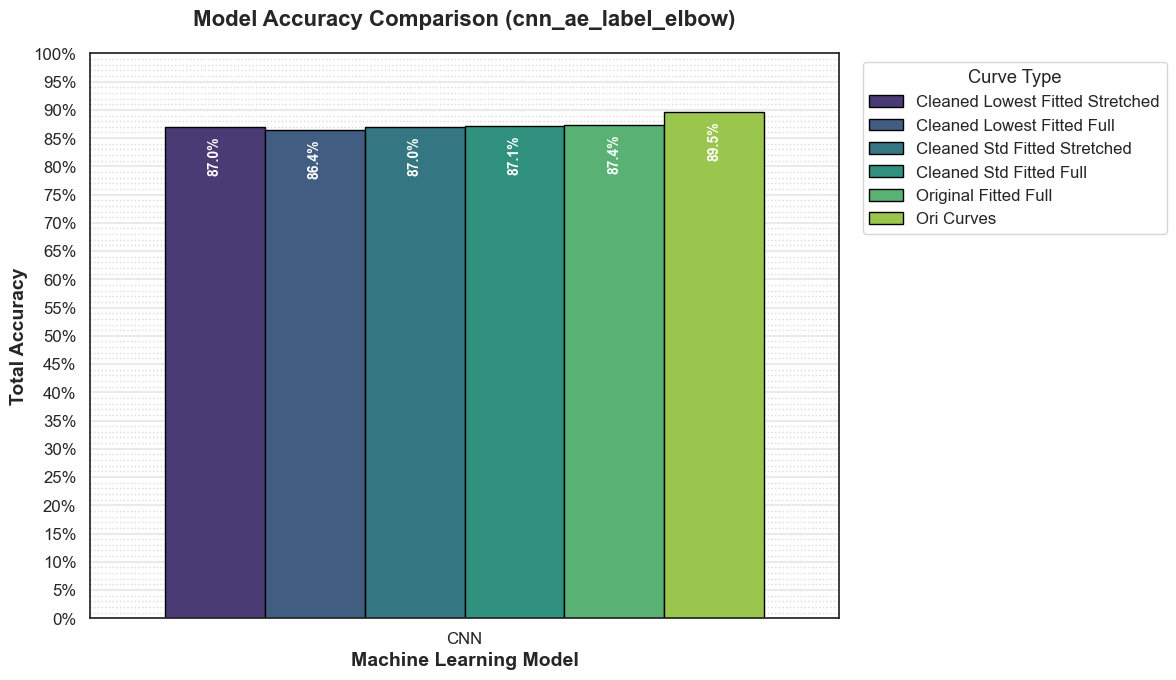

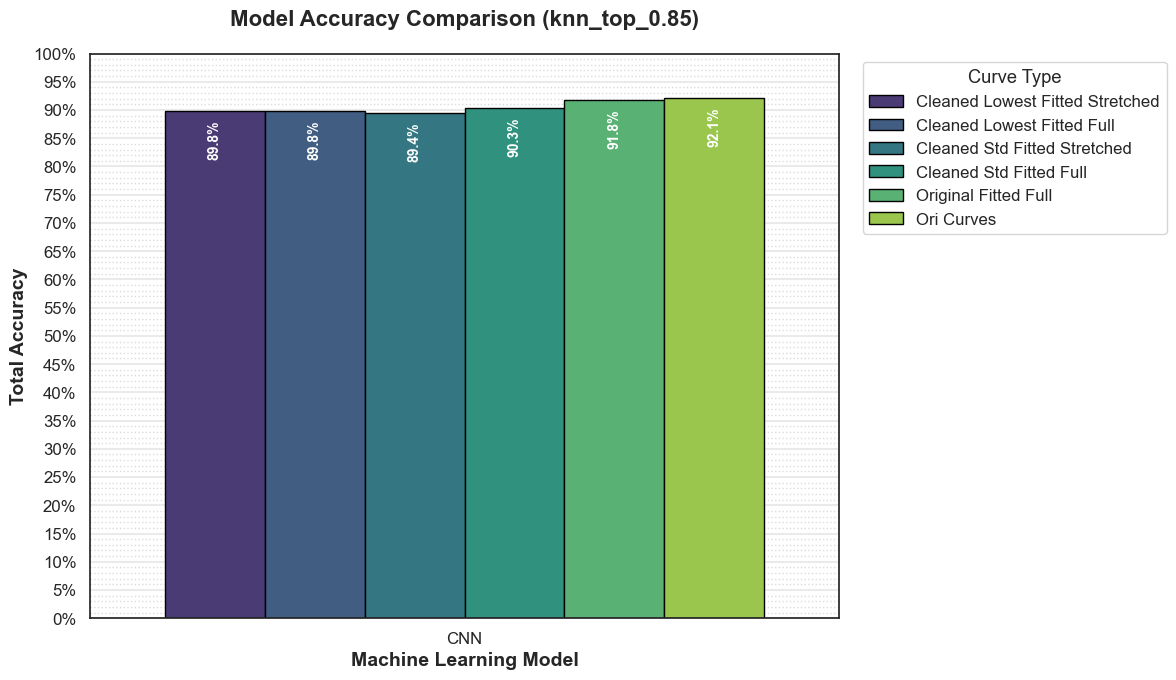

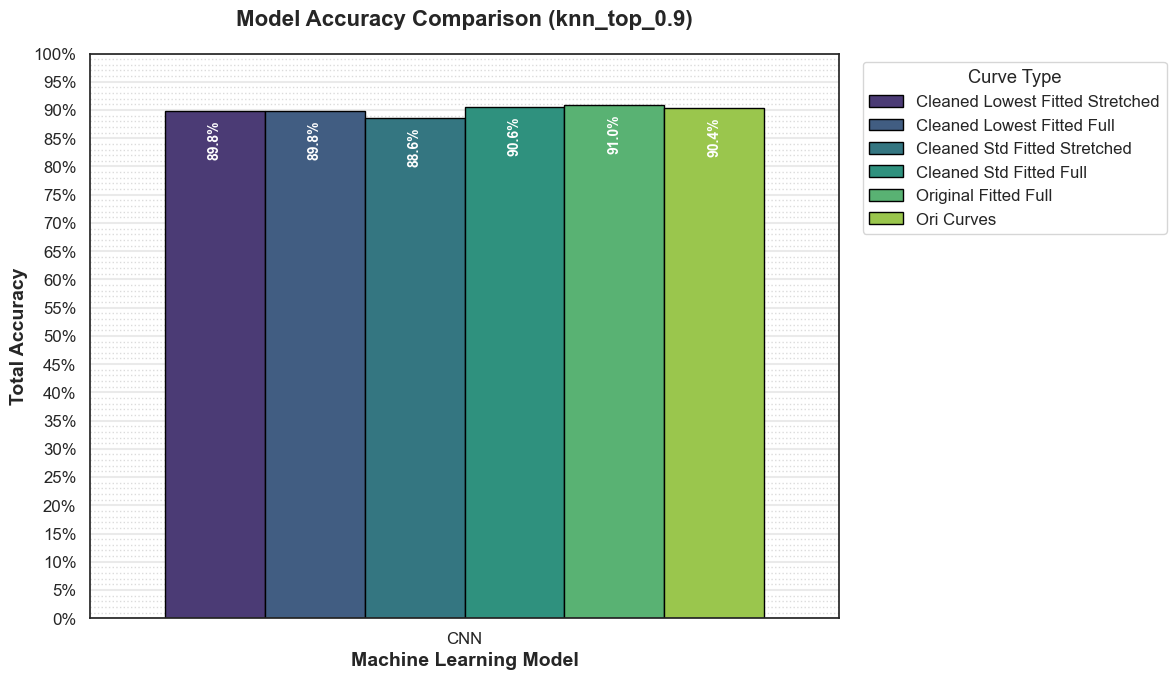

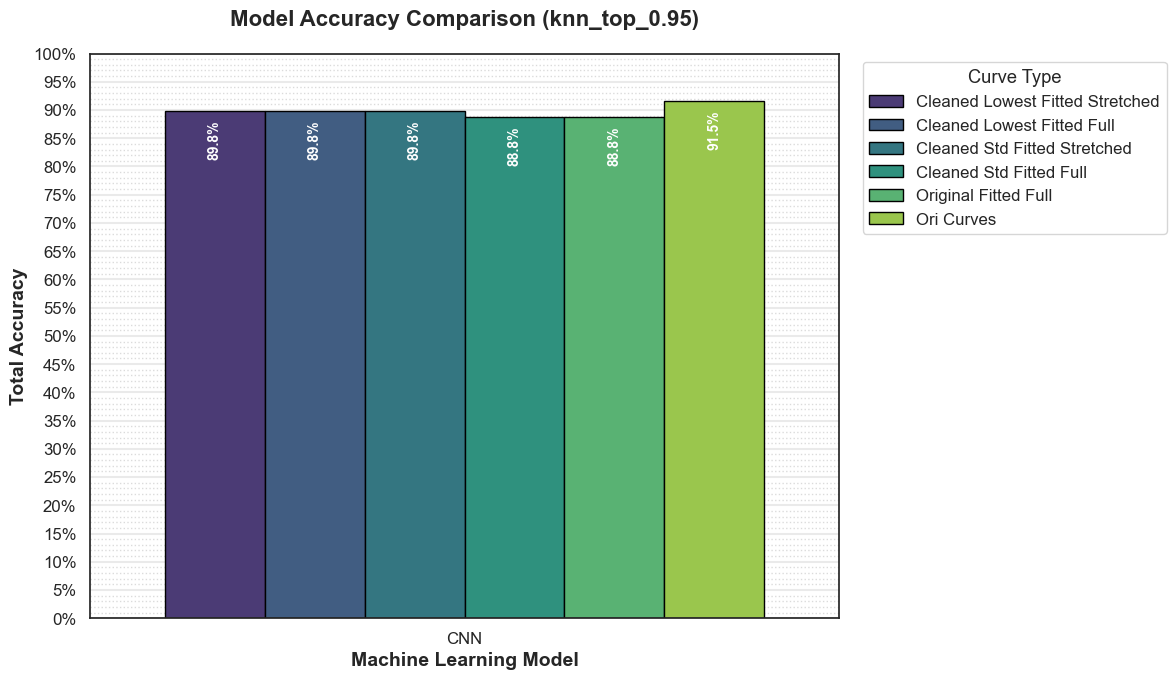

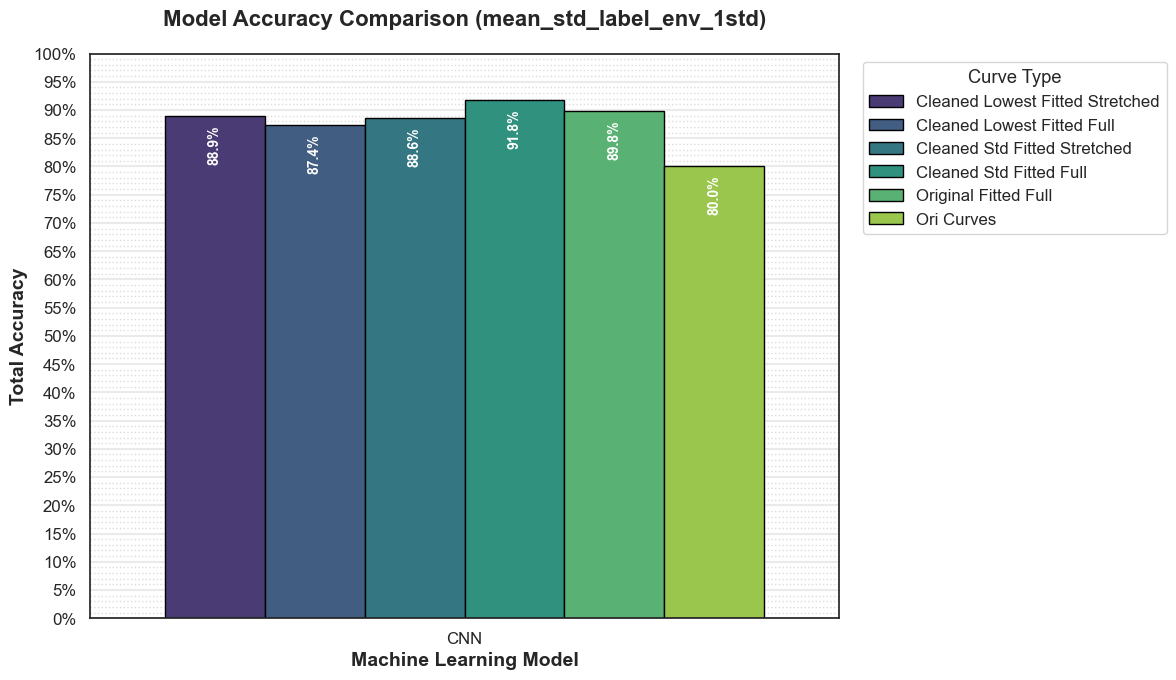

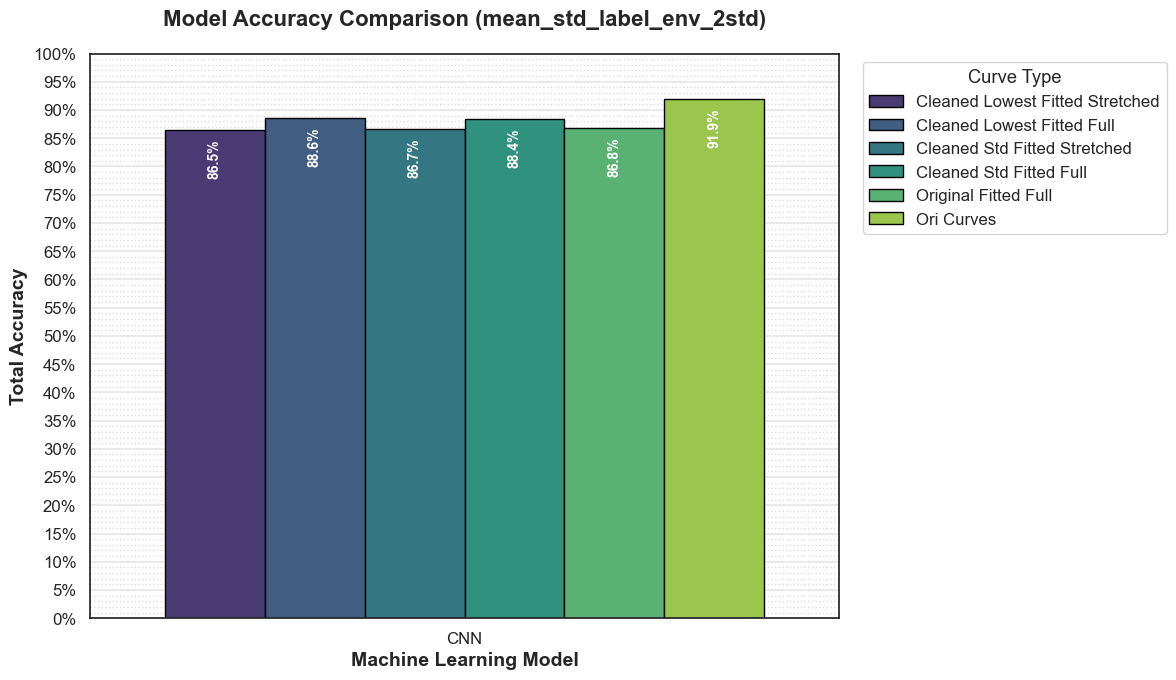

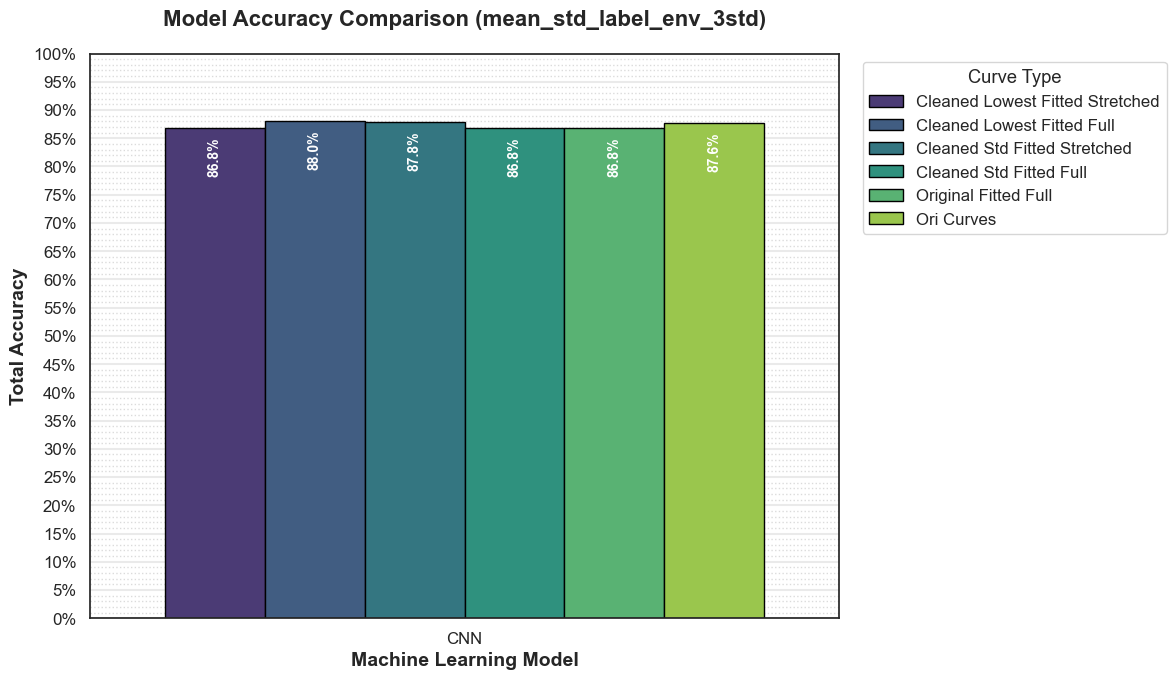

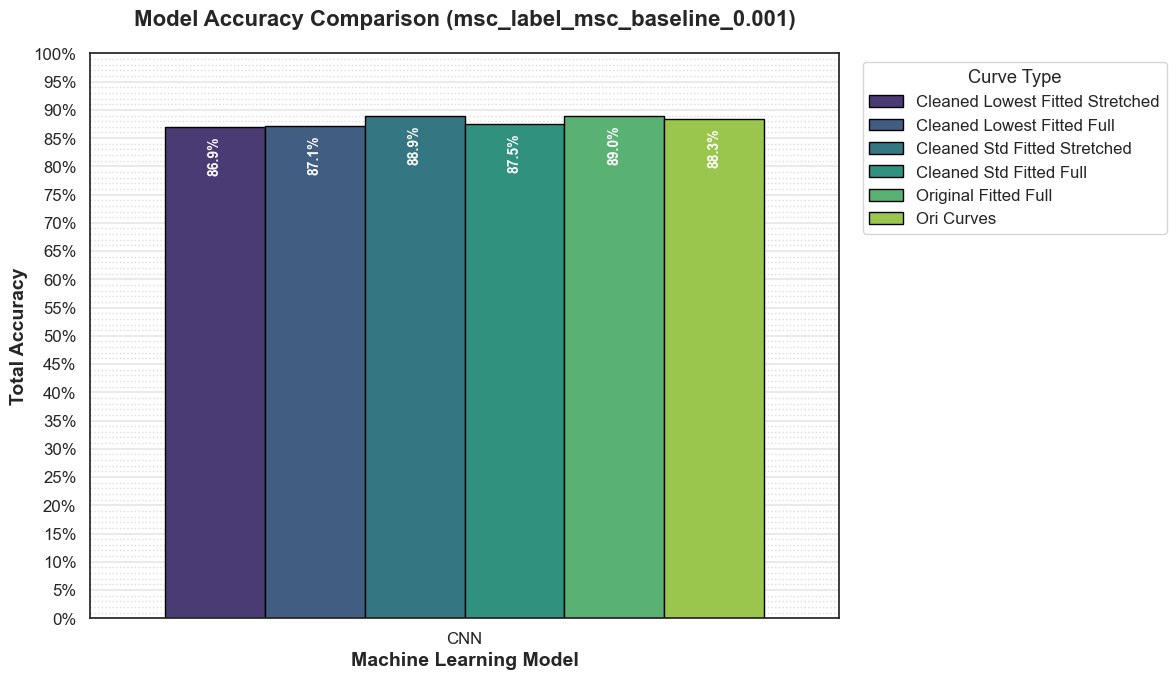

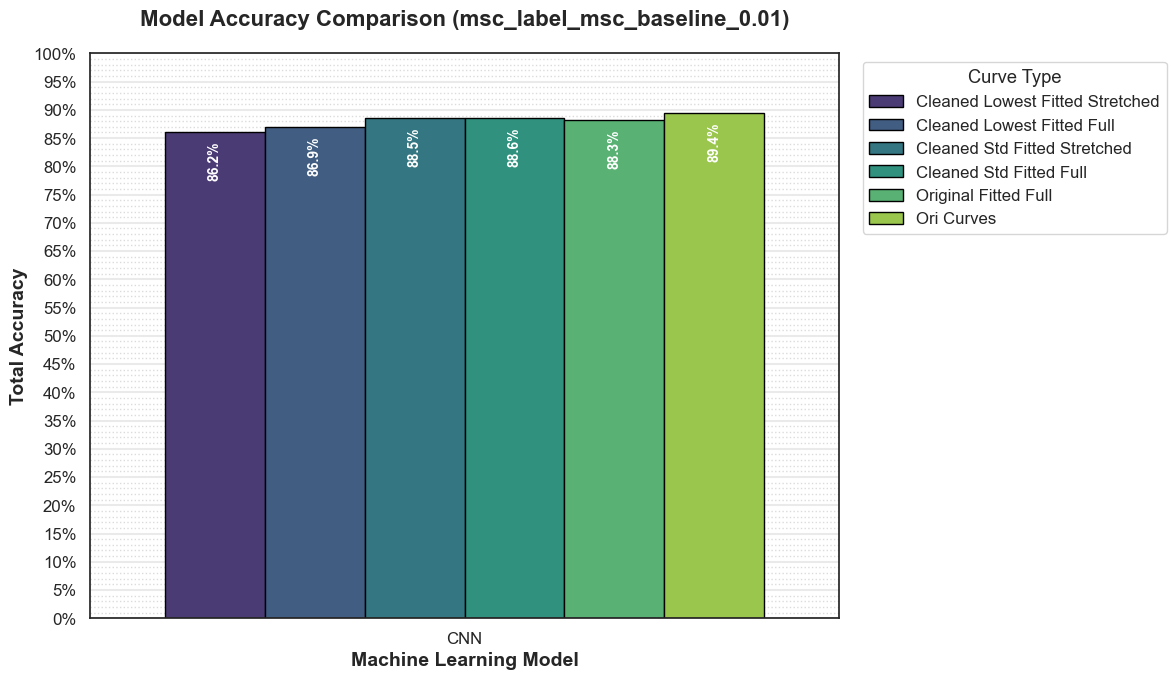

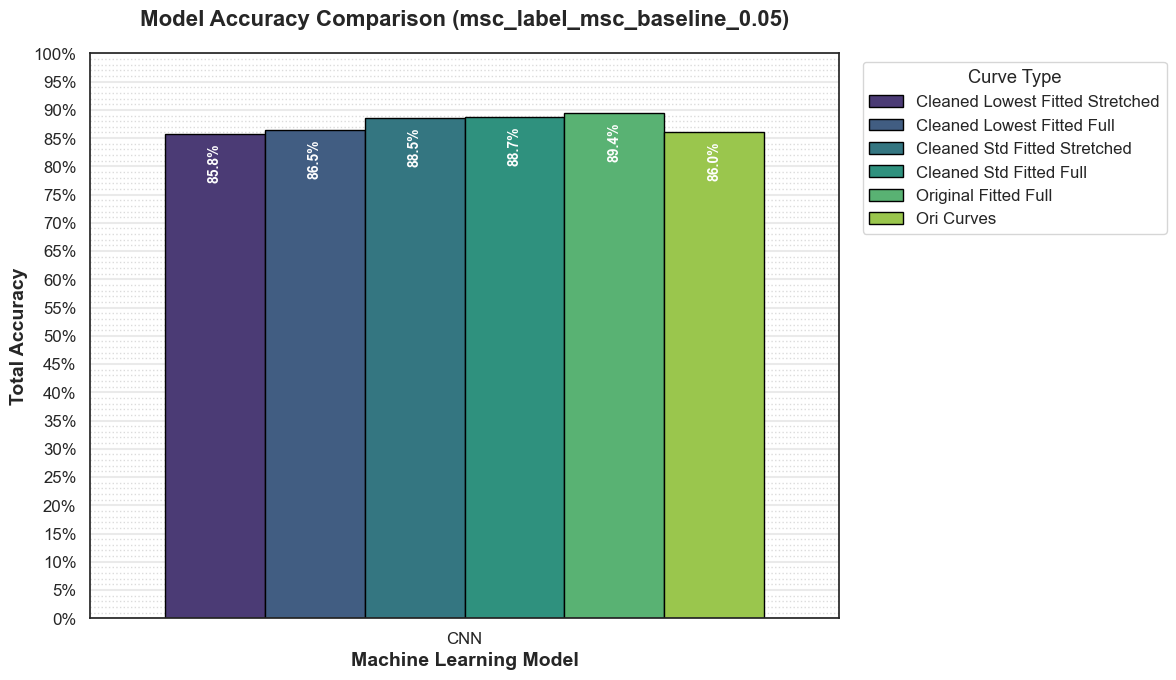

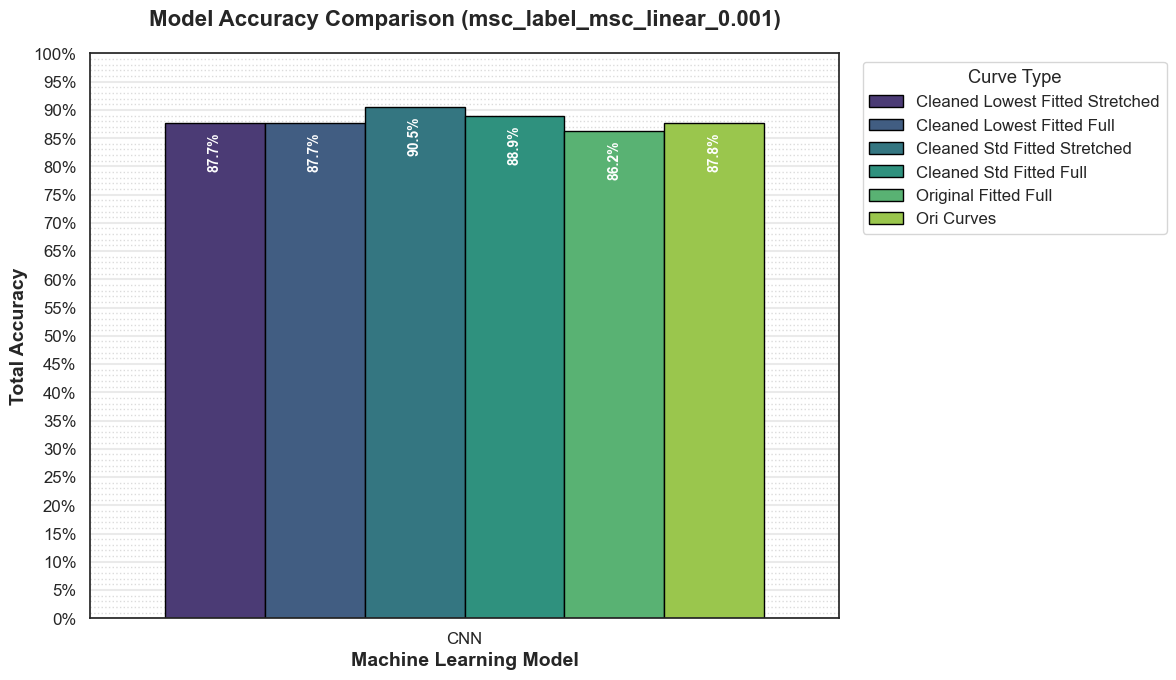

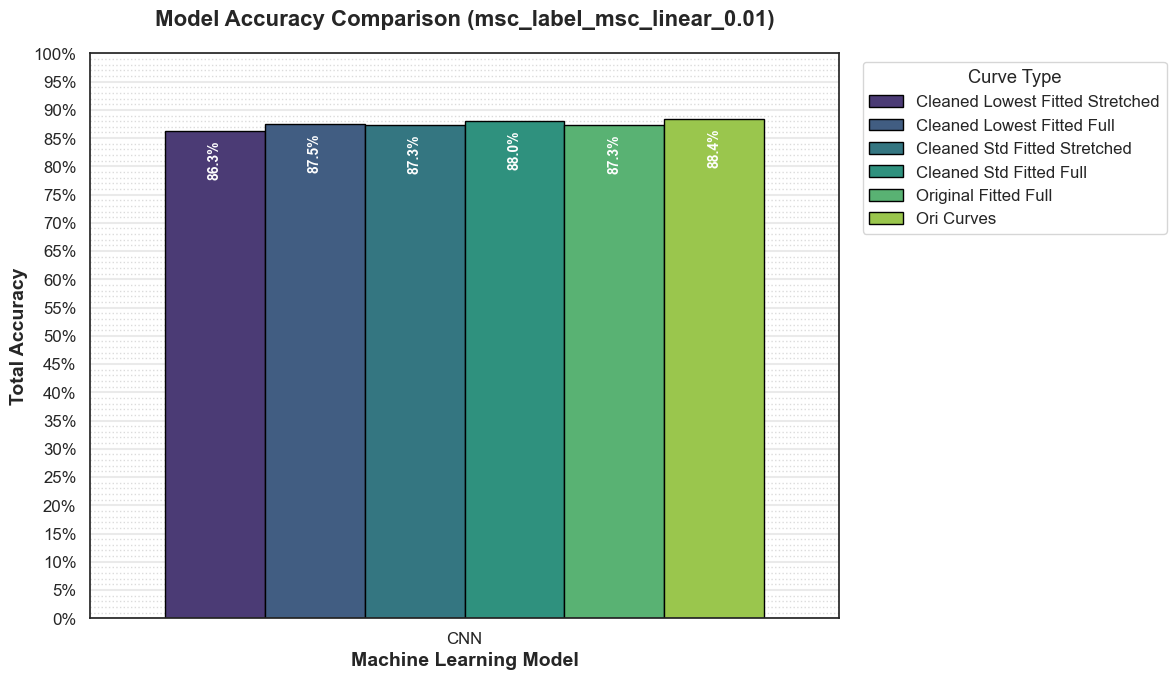

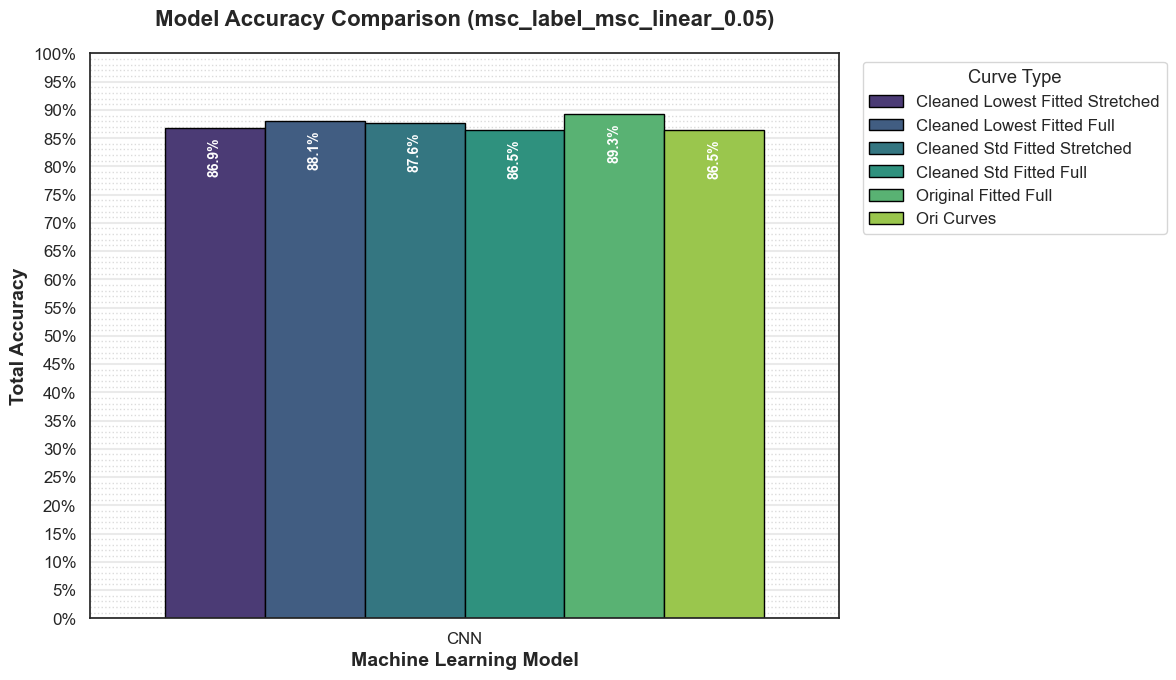

In [66]:
for filter in np.unique(result_df.outlier_filter.values):
# for filter in ["Baseline_None"]:
    sigfit_curves_compare = ["Ori Curves", "Original Fitted Full", "Cleaned Lowest Fitted Full", "Cleaned Lowest Fitted Stretched", "Cleaned Std Fitted Full", "Cleaned Std Fitted Stretched"]
    sigfit_training_compare = ["Reference"]
    sigfit_filter_compare = [filter]

    sigfit_compare_df = result_df[result_df["curve_name"].isin(sigfit_curves_compare) & result_df["training_mode"].isin(sigfit_training_compare) & result_df["outlier_filter"].isin(sigfit_filter_compare)]
    plot_accuracy_comparison_static(sigfit_compare_df, title=f"Model Accuracy Comparison ({filter})")

In [79]:
np.unique(result_df.curve_name.values)

array(['Avg Cleaned Lowest Fitted Full',
       'Avg Cleaned Lowest Fitted Stretched',
       'Avg Cleaned Std Fitted Full', 'Avg Cleaned Std Fitted Stretched',
       'Avg Fitted Full', 'Avg Fitted Stretched',
       'Cleaned Lowest Fitted Full', 'Cleaned Lowest Fitted Stretched',
       'Cleaned Std Fitted Full', 'Cleaned Std Fitted Stretched',
       'Ori Curves', 'Ori Curves Avg', 'Original Fitted Full',
       'Original Fitted Stretched'], dtype=object)

## MODEL PERFORMANCE COMPARISON

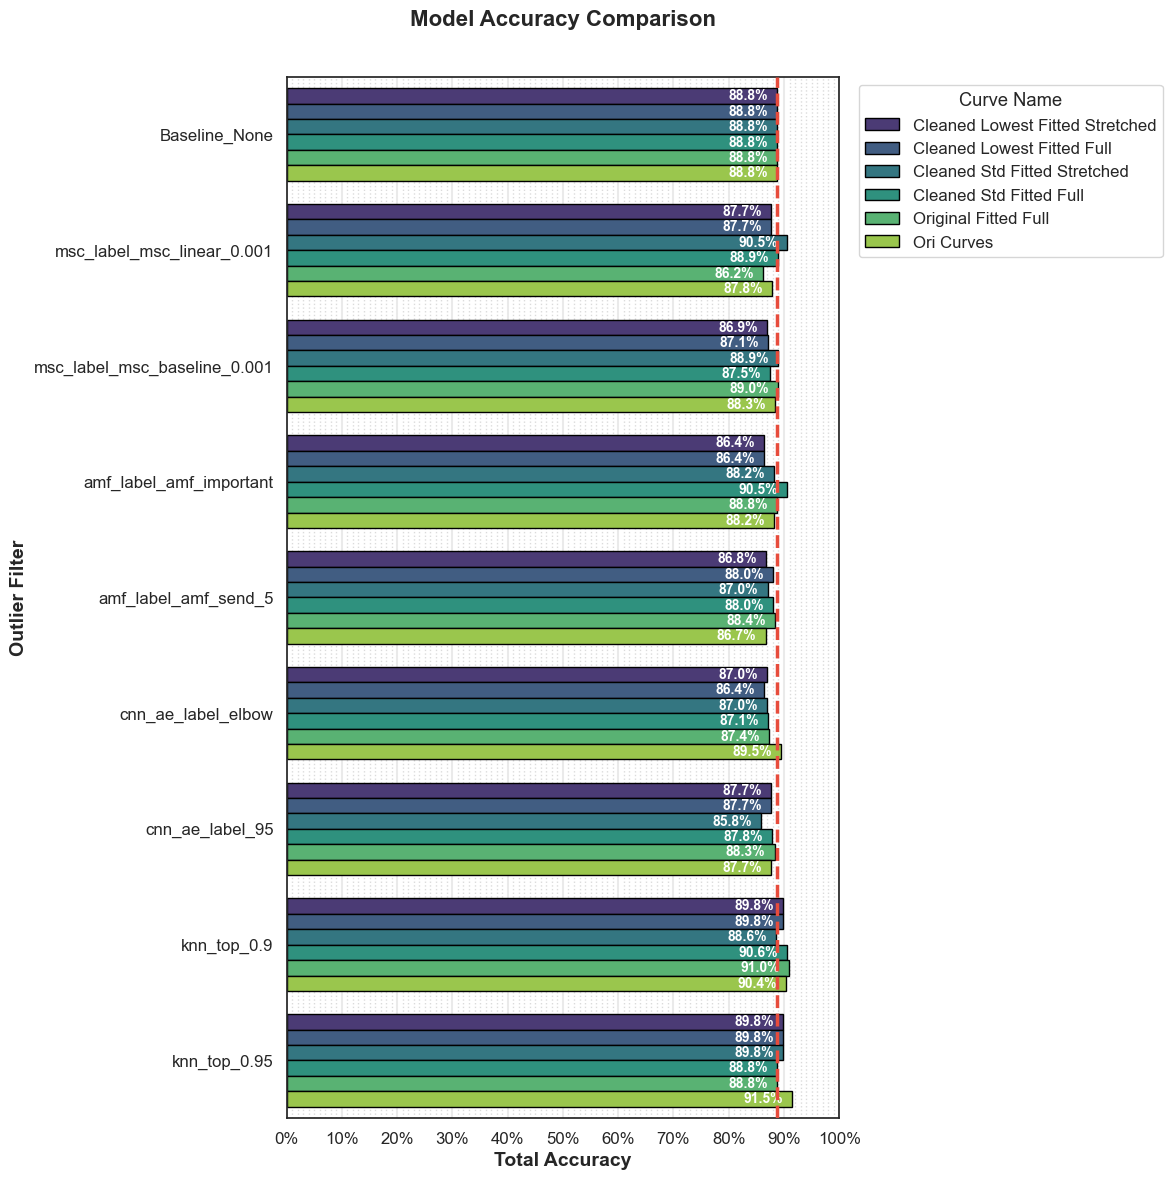

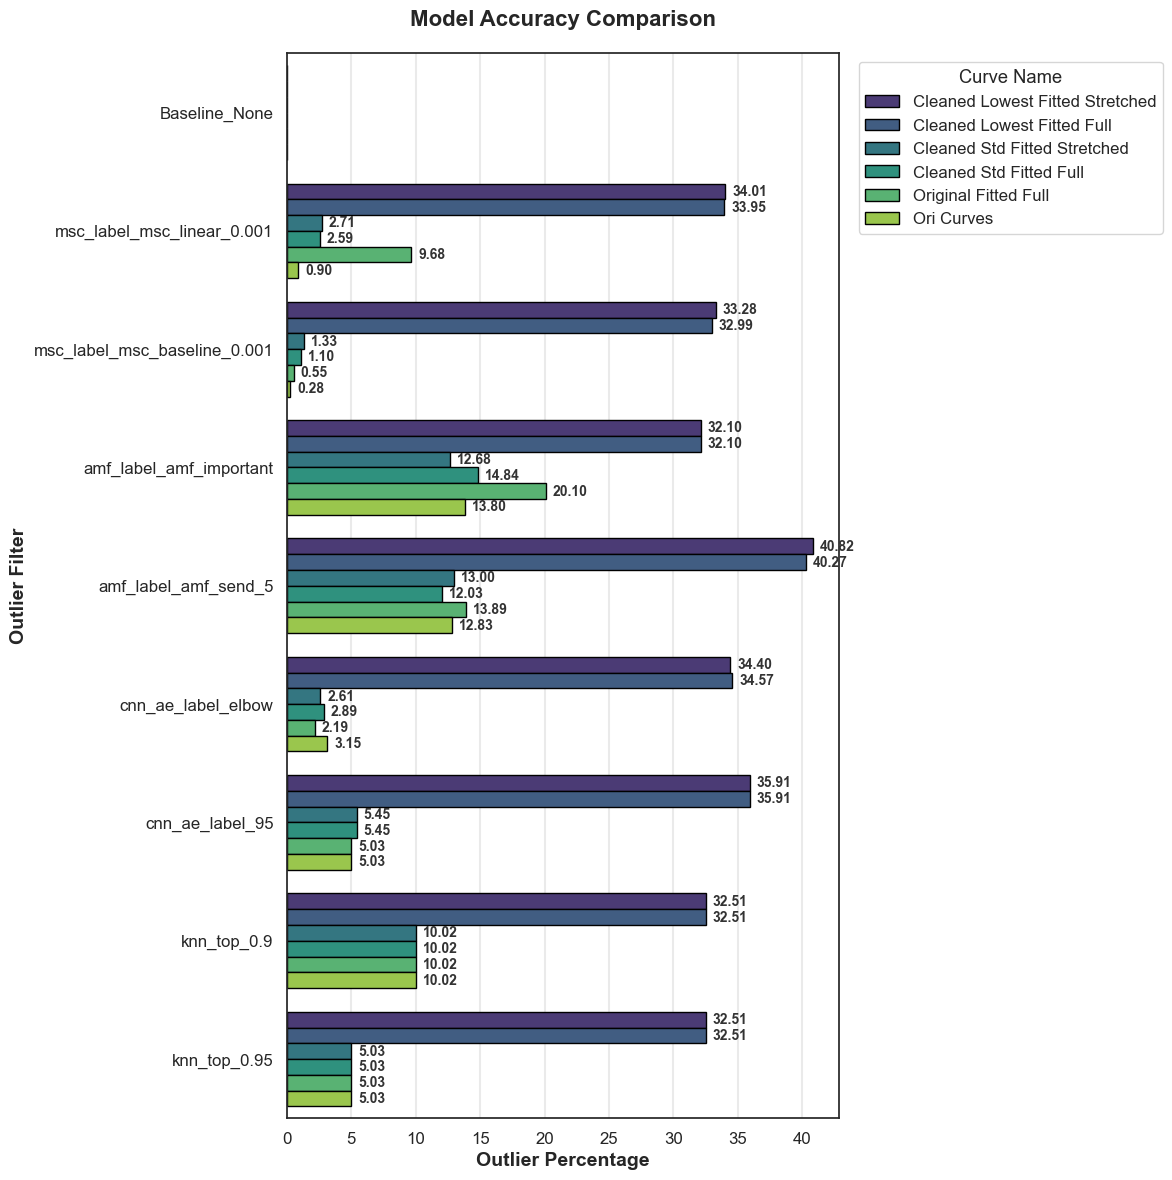

In [80]:
# sigfit_curves_compare = ["Ori Curves", "Original Fitted Full", "Cleaned Lowest Fitted Full", "Cleaned Lowest Fitted Stretched", "Cleaned Std Fitted Full", "Cleaned Std Fitted Stretched"]
filtered_df_allmodes = result_df[(result_df["model"] == "CNN")]
df_mask = (filtered_df_allmodes["training_mode"] == "Reference") & \
            (filtered_df_allmodes["outlier_filter"].isin(["Baseline_None", "msc_label_msc_linear_0.001", "msc_label_msc_baseline_0.001", "amf_label_amf_important",  "amf_label_amf_send_5", "knn_top_0.9", "knn_top_0.95", "cnn_ae_label_95", "cnn_ae_label_elbow"]))  & \
            (filtered_df_allmodes["curve_name"].isin(['Ori Curves', 'Original Fitted Full', 'Cleaned Std Fitted Full', 'Cleaned Std Fitted Stretched', 'Cleaned Lowest Fitted Full', 'Cleaned Lowest Fitted Stretched']))

filtered_df = filtered_df_allmodes[df_mask]
# filtered_df = result_df[(result_df["model"] == "CNN") & (result_df["training_mode"] == "Reference")]

plot_flexible_grouped_bar(
    df=filtered_df,
    x_col="outlier_filter",
    y_col="total_accuracy",
    hue_col="curve_name",
    title="Model Accuracy Comparison\n",
    is_percentage=True,
    is_horizontal=True,
    baseline_value= result_df[(result_df["curve_name"] == "Ori Curves") & (result_df["outlier_filter"] == "Baseline_None") & (result_df["training_mode"] == "Reference")  & (result_df["model"] == "CNN")].total_accuracy.values[0]
)

# filtered_df = filtered_df_allmodes[(filtered_df_allmodes["training_mode"] == "Native")]
# plot_flexible_grouped_bar(
#     df=filtered_df,
#     x_col="outlier_filter",
#     y_col="total_accuracy",
#     hue_col="curve_name",
#     title="Model Accuracy Comparison - Native",
#     is_percentage=True,
#     is_horizontal=True,
#     baseline_value= result_df[(result_df["curve_name"] == "Ori Curves") & (result_df["outlier_filter"] == "Baseline_None") & (result_df["training_mode"] == "Native")  & (result_df["model"] == "CNN")].total_accuracy.values[0]
# )

plot_flexible_grouped_bar(
    df=filtered_df,
    x_col="outlier_filter",
    y_col="outlier_percentage",
    hue_col="curve_name",
    title="Model Accuracy Comparison",
    is_percentage=False,
    is_horizontal=True,
)

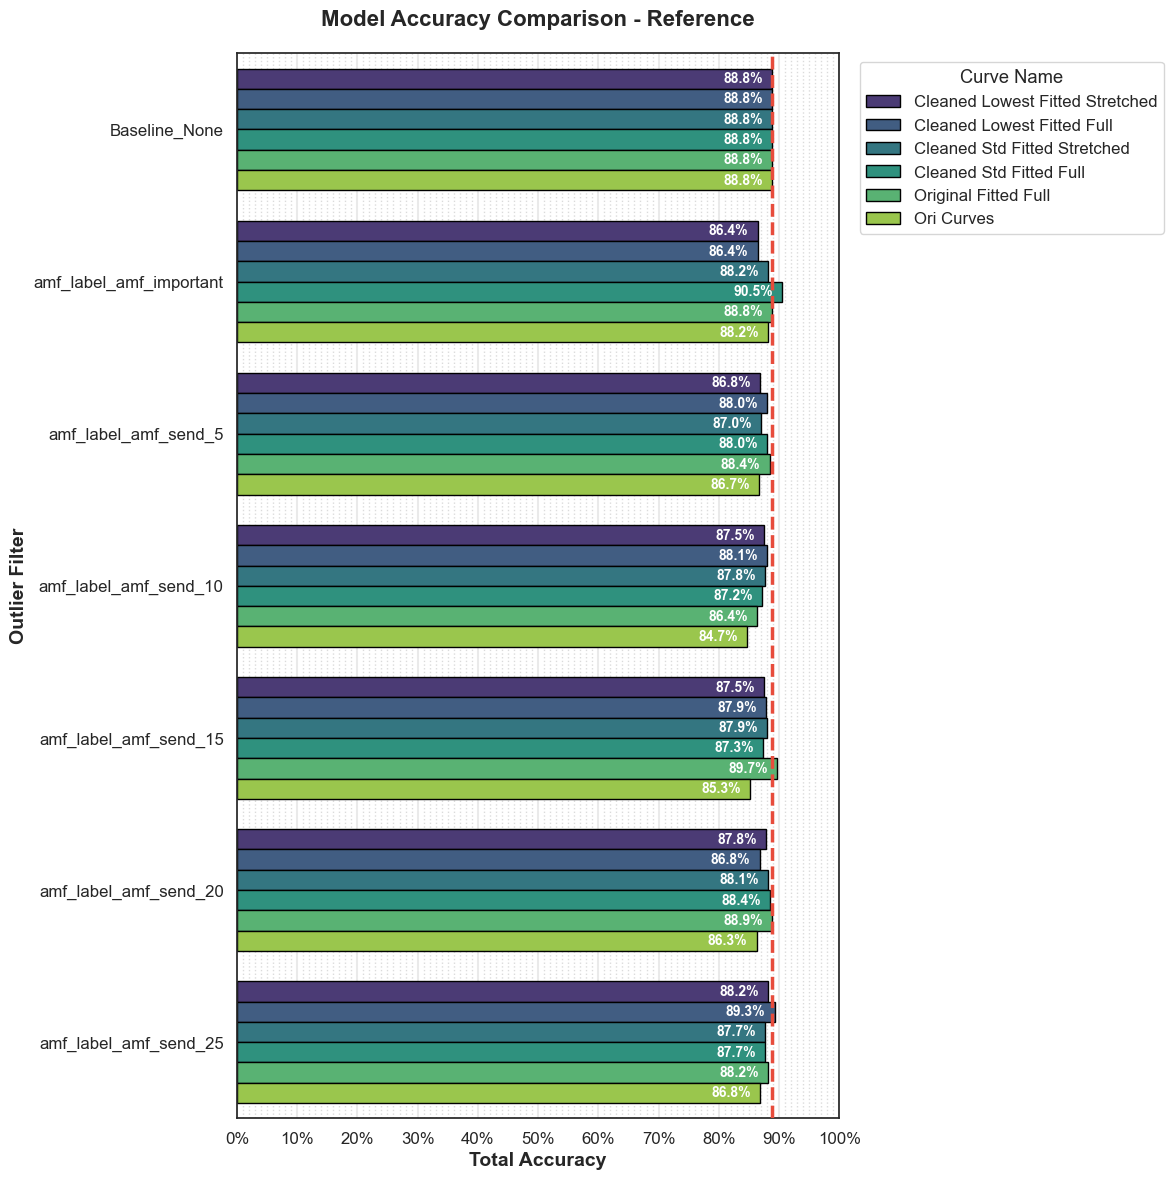

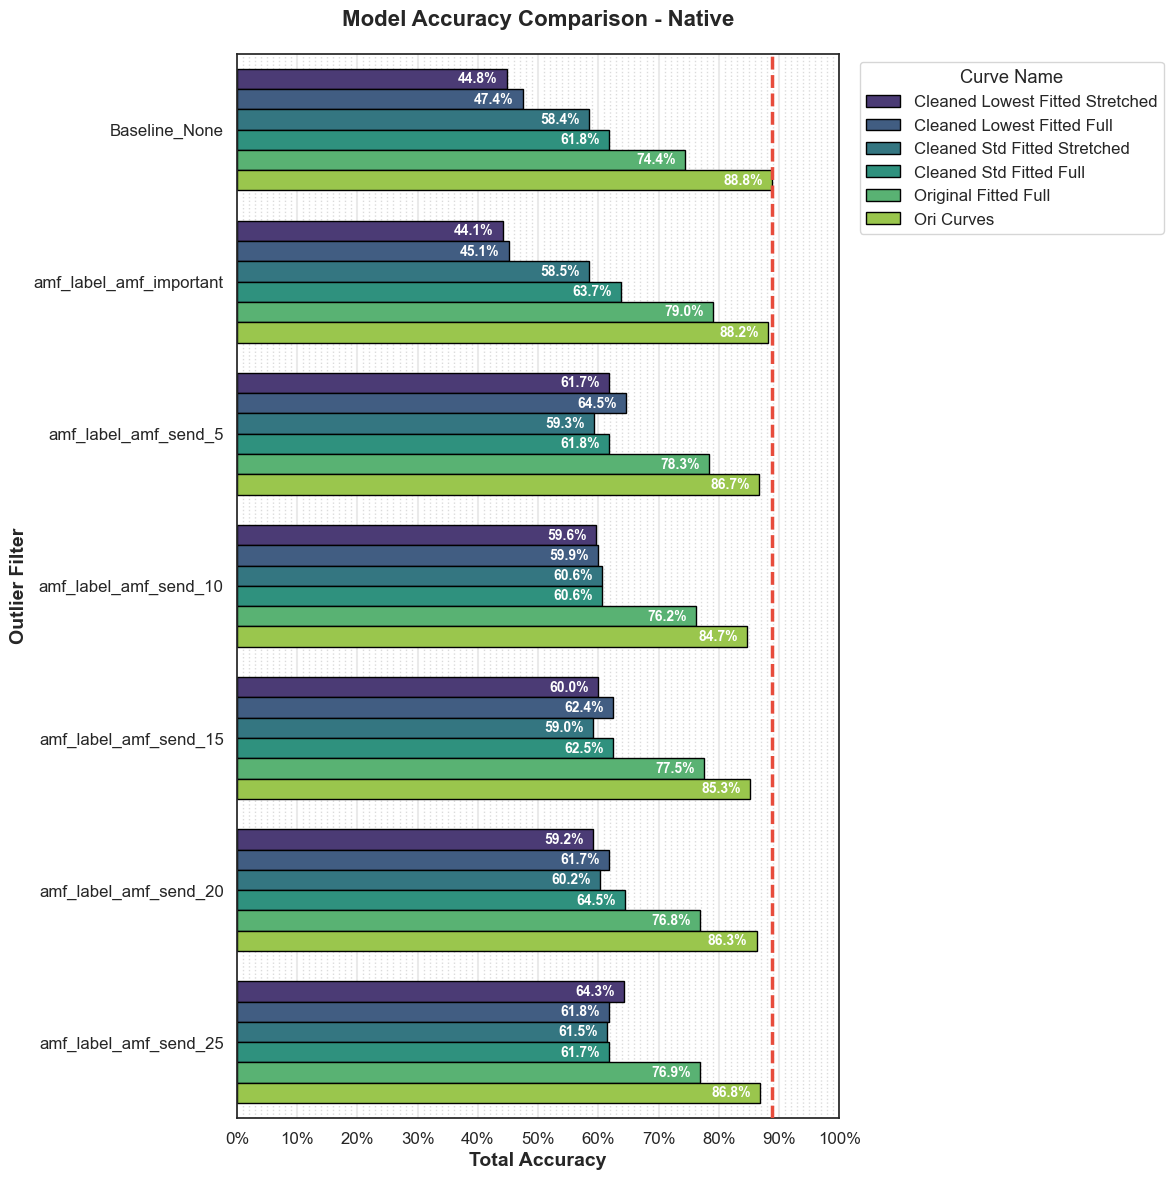

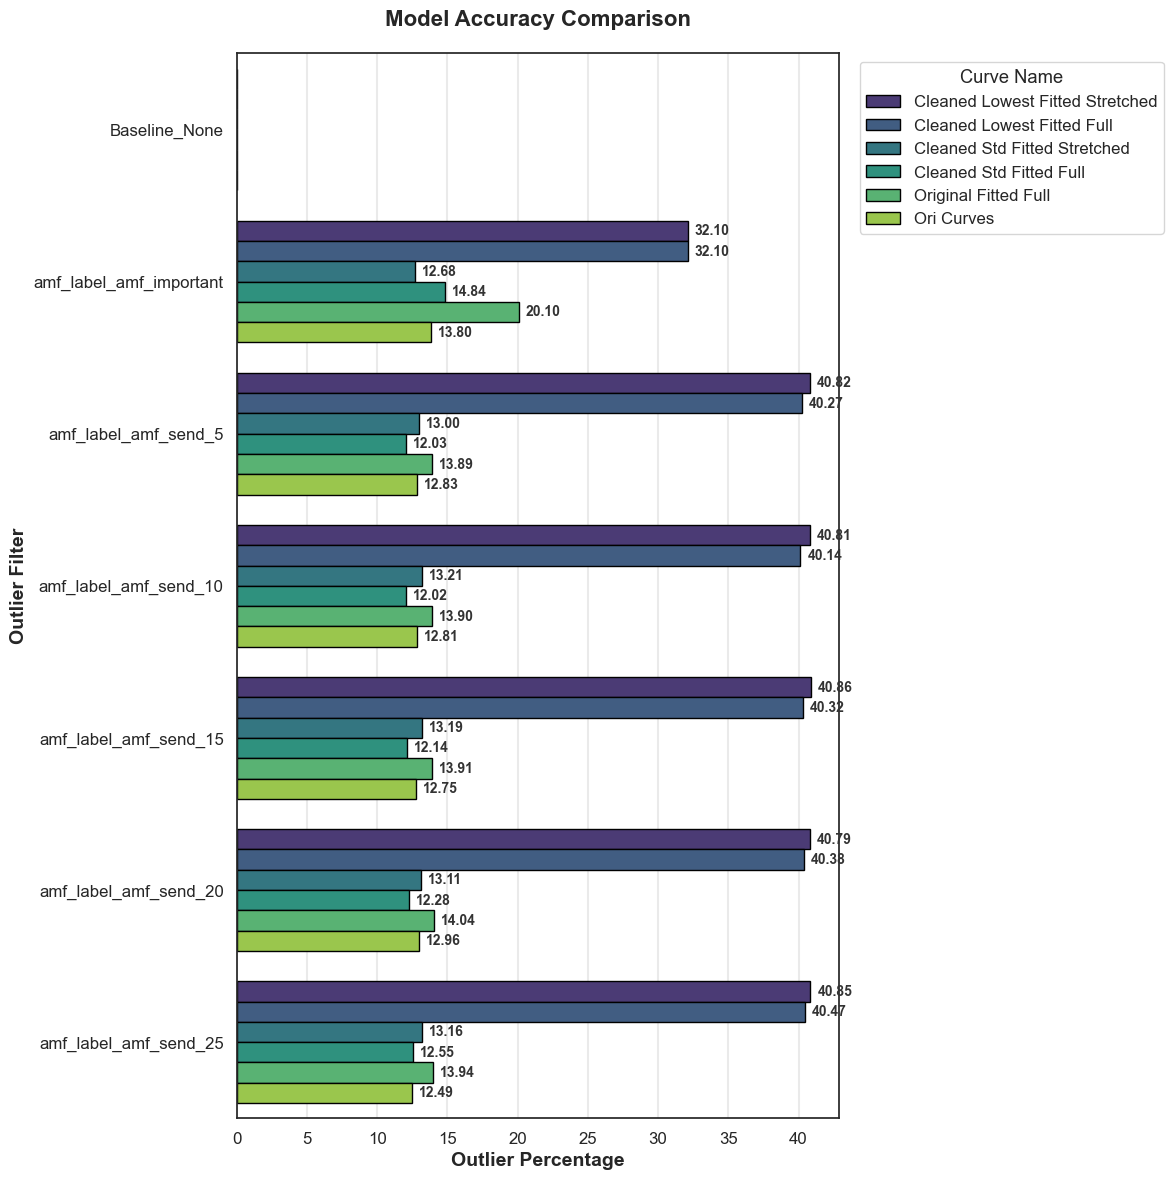

In [68]:
sigfit_curves_compare = ["Ori Curves", "Original Fitted Full", "Cleaned Lowest Fitted Full", "Cleaned Lowest Fitted Stretched", "Cleaned Std Fitted Full", "Cleaned Std Fitted Stretched"]
filtered_df_allmodes = result_df[(result_df["outlier_filter"].isin(['Baseline_None', 'amf_label_amf_important', 'amf_label_amf_send_10', 'amf_label_amf_send_15', 'amf_label_amf_send_20', 'amf_label_amf_send_25', 'amf_label_amf_send_5'])) & (result_df["model"] == "CNN") & result_df["curve_name"].isin(sigfit_curves_compare)]
filtered_df = filtered_df_allmodes[(filtered_df_allmodes["training_mode"] == "Reference")]
# filtered_df = result_df[(result_df["model"] == "CNN") & (result_df["training_mode"] == "Reference")]

plot_flexible_grouped_bar(
    df=filtered_df,
    x_col="outlier_filter",
    y_col="total_accuracy",
    hue_col="curve_name",
    title="Model Accuracy Comparison - Reference",
    is_percentage=True,
    is_horizontal=True,
    baseline_value= result_df[(result_df["curve_name"] == "Ori Curves") & (result_df["outlier_filter"] == "Baseline_None") & (result_df["training_mode"] == "Reference")  & (result_df["model"] == "CNN")].total_accuracy.values[0]
)

filtered_df = filtered_df_allmodes[(filtered_df_allmodes["training_mode"] == "Native")]
plot_flexible_grouped_bar(
    df=filtered_df,
    x_col="outlier_filter",
    y_col="total_accuracy",
    hue_col="curve_name",
    title="Model Accuracy Comparison - Native",
    is_percentage=True,
    is_horizontal=True,
    baseline_value= result_df[(result_df["curve_name"] == "Ori Curves") & (result_df["outlier_filter"] == "Baseline_None") & (result_df["training_mode"] == "Native")  & (result_df["model"] == "CNN")].total_accuracy.values[0]
)

plot_flexible_grouped_bar(
    df=filtered_df,
    x_col="outlier_filter",
    y_col="outlier_percentage",
    hue_col="curve_name",
    title="Model Accuracy Comparison",
    is_percentage=False,
    is_horizontal=True,
)

In [69]:
result_df.sort_values("total_accuracy", ascending=False).head(15)

,curve_name,training_mode,outlier_filter,model,outlier_percentage,total_accuracy,accuracy_well_0,accuracy_well_1,accuracy_well_2,accuracy_well_3,accuracy_well_4,accuracy_well_5,accuracy_well_6,accuracy_well_7,accuracy_well_8,accuracy_well_9,accuracy_well_avg
597,Ori Curves Avg,Reference,mean_std_label_env_1std,CNN,65.52,0.930120,0.820513,0.920000,0.333333,0.981132,1.000000,0.848485,1.000000,1.000000,0.854167,0.978723,0.873635
606,Ori Curves Avg,Reference,knn_top_0.85,CNN,15.04,0.921799,0.753623,0.865248,0.750000,0.959459,0.979592,0.838710,1.000000,0.571429,0.974576,0.934959,0.862760
657,Ori Curves,Reference,knn_top_0.85,CNN,15.04,0.920821,0.811594,0.780142,0.416667,0.979730,0.993197,0.935484,0.993671,0.500000,0.915254,0.983740,0.830948
649,Ori Curves,Reference,mean_std_label_env_2std,CNN,56.84,0.919231,0.897436,0.774194,0.857143,0.944444,0.961039,0.923077,1.000000,0.250000,0.900000,0.983333,0.849067
628,Ori Curves,Native,mean_std_label_env_2std,CNN,56.84,0.919231,0.897436,0.774194,0.857143,0.944444,0.961039,0.923077,1.000000,0.250000,0.900000,0.983333,0.849067
444,Cleaned Std Fitted Full,Reference,mean_std_label_env_1std,CNN,48.15,0.918269,0.917808,0.816901,0.444444,0.955556,0.974684,0.916667,1.000000,0.142857,0.885714,0.960526,0.801516
555,Original Fitted Full,Reference,knn_top_0.85,CNN,15.04,0.917889,0.855072,0.872340,0.166667,0.986486,0.945578,0.838710,0.993671,0.357143,0.906780,1.000000,0.792245
504,Original Fitted Stretched,Reference,knn_top_0.85,CNN,15.04,0.917889,0.855072,0.872340,0.166667,0.986486,0.945578,0.838710,0.993671,0.357143,0.906780,1.000000,0.792245
608,Ori Curves Avg,Reference,knn_top_0.95,CNN,5.03,0.916958,0.923077,0.866242,0.692308,0.951807,0.963636,0.865385,0.982955,0.437500,0.893939,0.927007,0.850386
659,Ori Curves,Reference,knn_top_0.95,CNN,5.03,0.915210,0.794872,0.853503,0.538462,0.957831,0.957576,0.875000,1.000000,0.250000,0.939394,0.963504,0.813014


In [70]:
result_df[(result_df["curve_name"] == "Ori Curves") & (result_df["outlier_filter"] == "Baseline_None") & (result_df["training_mode"] == "Native")  & (result_df["model"] == "CNN")].filter(like="accuracy").T

,609
total_accuracy,0.887874
accuracy_well_0,0.719512
accuracy_well_1,0.800000
accuracy_well_2,0.071429
accuracy_well_3,0.942857
accuracy_well_4,0.982659
accuracy_well_5,0.834862
accuracy_well_6,0.978495
accuracy_well_7,0.235294
accuracy_well_8,0.928058


In [71]:
result_df.sort_values("total_accuracy", ascending=False).head(15)

,curve_name,training_mode,outlier_filter,model,outlier_percentage,total_accuracy,accuracy_well_0,accuracy_well_1,accuracy_well_2,accuracy_well_3,accuracy_well_4,accuracy_well_5,accuracy_well_6,accuracy_well_7,accuracy_well_8,accuracy_well_9,accuracy_well_avg
597,Ori Curves Avg,Reference,mean_std_label_env_1std,CNN,65.52,0.930120,0.820513,0.920000,0.333333,0.981132,1.000000,0.848485,1.000000,1.000000,0.854167,0.978723,0.873635
606,Ori Curves Avg,Reference,knn_top_0.85,CNN,15.04,0.921799,0.753623,0.865248,0.750000,0.959459,0.979592,0.838710,1.000000,0.571429,0.974576,0.934959,0.862760
657,Ori Curves,Reference,knn_top_0.85,CNN,15.04,0.920821,0.811594,0.780142,0.416667,0.979730,0.993197,0.935484,0.993671,0.500000,0.915254,0.983740,0.830948
649,Ori Curves,Reference,mean_std_label_env_2std,CNN,56.84,0.919231,0.897436,0.774194,0.857143,0.944444,0.961039,0.923077,1.000000,0.250000,0.900000,0.983333,0.849067
628,Ori Curves,Native,mean_std_label_env_2std,CNN,56.84,0.919231,0.897436,0.774194,0.857143,0.944444,0.961039,0.923077,1.000000,0.250000,0.900000,0.983333,0.849067
444,Cleaned Std Fitted Full,Reference,mean_std_label_env_1std,CNN,48.15,0.918269,0.917808,0.816901,0.444444,0.955556,0.974684,0.916667,1.000000,0.142857,0.885714,0.960526,0.801516
555,Original Fitted Full,Reference,knn_top_0.85,CNN,15.04,0.917889,0.855072,0.872340,0.166667,0.986486,0.945578,0.838710,0.993671,0.357143,0.906780,1.000000,0.792245
504,Original Fitted Stretched,Reference,knn_top_0.85,CNN,15.04,0.917889,0.855072,0.872340,0.166667,0.986486,0.945578,0.838710,0.993671,0.357143,0.906780,1.000000,0.792245
608,Ori Curves Avg,Reference,knn_top_0.95,CNN,5.03,0.916958,0.923077,0.866242,0.692308,0.951807,0.963636,0.865385,0.982955,0.437500,0.893939,0.927007,0.850386
659,Ori Curves,Reference,knn_top_0.95,CNN,5.03,0.915210,0.794872,0.853503,0.538462,0.957831,0.957576,0.875000,1.000000,0.250000,0.939394,0.963504,0.813014


# KINETIC FEATURE ILUSTRATION

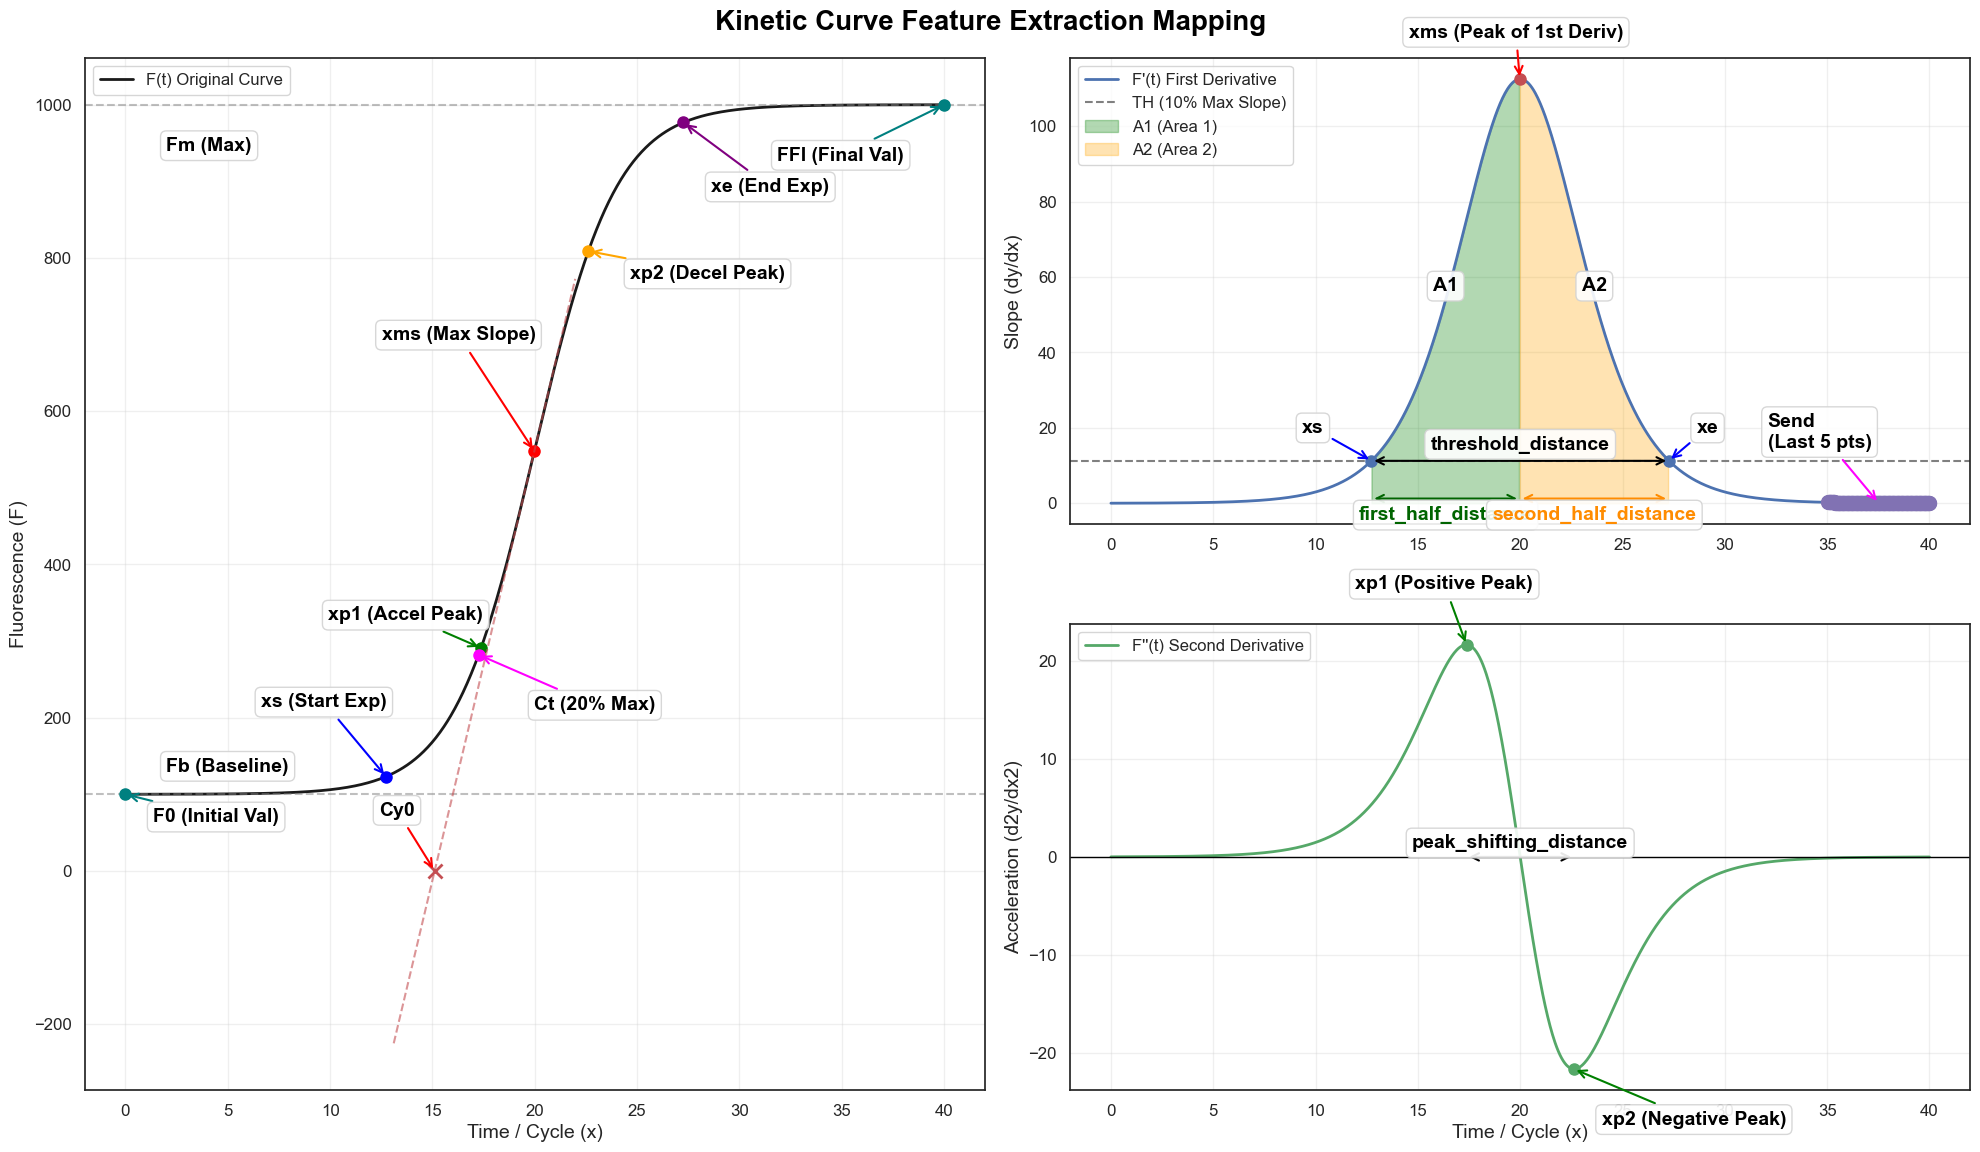

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Generate smoothed mock sigmoid data
x = np.linspace(0, 40, 1000)
Fb, Fm, Sc, Cs = 100, 1000, 0.5, 20
y = Fb + (Fm - Fb) / (1 + np.exp(-Sc * (x - Cs))) 

# First and second derivatives
dy = np.gradient(y, x)
d2y = np.gradient(dy, x)

# Calculate original features
xms_idx = np.argmax(dy)
xms = x[xms_idx]
TH = 0.1 * dy[xms_idx]
above_th = np.where(dy > TH)[0]
xs_idx, xe_idx = above_th[0], above_th[-1]
xs, xe = x[xs_idx], x[xe_idx]
xp1_idx = np.argmax(d2y)
xp2_idx = np.argmin(d2y)
xp1, xp2 = x[xp1_idx], x[xp2_idx]
Ct_target = Fb + 0.2 * (Fm - Fb)
Ct_idx = np.where(y >= Ct_target)[0][0]
Ct = x[Ct_idx]
Cy0 = xms - (y[xms_idx] / dy[xms_idx])

# Initialize the plot with GridSpec for a 2x2 layout
fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 2, figure=fig)

# Assign subplots to grid positions
ax1 = fig.add_subplot(gs[:, 0])             # Col 0, spans both rows
ax2 = fig.add_subplot(gs[0, 1], sharex=ax1) # Col 1, row 0
ax3 = fig.add_subplot(gs[1, 1], sharex=ax1) # Col 1, row 1

fig.suptitle('Kinetic Curve Feature Extraction Mapping', fontsize=20, fontweight='bold', color='black', y=0.96)

annotation_size = 14

# Uniform styling for ALL text
TEXT_PROP = dict(color='black', fontweight='bold', fontsize=annotation_size, 
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="lightgray", alpha=0.9))

# ==========================================
# SUBPLOT 1: Original Curve
# ==========================================
ax1.plot(x, y, 'k-', lw=2, label='F(t) Original Curve')
ax1.set_ylabel('Fluorescence (F)', fontsize=14)
ax1.set_xlabel('Time / Cycle (x)', fontsize=14)
ax1.grid(True, alpha=0.3)

ax1.axhline(Fb, color='gray', linestyle='--', alpha=0.5)
ax1.text(2, Fb + 30, 'Fb (Baseline)', **TEXT_PROP)
ax1.axhline(Fm, color='gray', linestyle='--', alpha=0.5)
ax1.text(2, Fm - 60, 'Fm (Max)', **TEXT_PROP)

# Define precise xytext offsets to guarantee NO overlapping text
points = [
    (xs, y[xs_idx], 'xs (Start Exp)', 'blue', (-90, 50)),
    (xe, y[xe_idx], 'xe (End Exp)', 'purple', (20, -50)),
    (xms, y[xms_idx], 'xms (Max Slope)', 'red', (-110, 80)),
    (xp1, y[xp1_idx], 'xp1 (Accel Peak)', 'green', (-110, 20)),
    (xp2, y[xp2_idx], 'xp2 (Decel Peak)', 'orange', (30, -20)),
    (Ct, y[Ct_idx], 'Ct (20% Max)', 'magenta', (40, -40)),
    (x[0], y[0], 'F0 (Initial Val)', 'teal', (20, -20)),
    (x[-1], y[-1], 'FFI (Final Val)', 'teal', (-120, -40))
]

for px, py, label, color, offset in points:
    ax1.plot(px, py, marker='o', markersize=8, color=color)
    ax1.annotate(label, (px, py), xytext=offset, textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color=color, lw=1.5), **TEXT_PROP)

# Cy0 Tangent Line
tangent_x = np.linspace(Cy0 - 2, xms + 2, 100)
tangent_y = dy[xms_idx] * (tangent_x - xms) + y[xms_idx]
ax1.plot(tangent_x, tangent_y, 'r--', alpha=0.6)
ax1.plot(Cy0, 0, 'rx', markersize=10, markeredgewidth=2)
ax1.annotate('Cy0', (Cy0, 0), xytext=(-40, 40), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5), **TEXT_PROP)
ax1.legend(loc='upper left', fontsize=12)


# ==========================================
# SUBPLOT 2: First Derivative
# ==========================================
ax2.plot(x, dy, 'b-', lw=2, label="F'(t) First Derivative")
ax2.set_ylabel('Slope (dy/dx)', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.axhline(TH, color='gray', linestyle='--', label='TH (10% Max Slope)')

# Critical points on 1st Deriv
ax2.plot(xms, dy[xms_idx], 'ro', markersize=8)
ax2.annotate('xms (Peak of 1st Deriv)', (xms, dy[xms_idx]), xytext=(-80, 30), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5), **TEXT_PROP)

ax2.plot([xs, xe], [dy[xs_idx], dy[xe_idx]], 'bo', markersize=8)
ax2.annotate('xs', (xs, dy[xs_idx]), xytext=(-50, 20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='blue', lw=1.5), **TEXT_PROP)
ax2.annotate('xe', (xe, dy[xe_idx]), xytext=(20, 20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='blue', lw=1.5), **TEXT_PROP)

# Area Shading
ax2.fill_between(x[xs_idx:xms_idx], dy[xs_idx:xms_idx], alpha=0.3, color='green', label='A1 (Area 1)')
ax2.fill_between(x[xms_idx:xe_idx], dy[xms_idx:xe_idx], alpha=0.3, color='orange', label='A2 (Area 2)')
ax2.text((xs+xms)/2, dy[xms_idx]/2, 'A1', ha='center', **TEXT_PROP)
ax2.text((xms+xe)/2, dy[xms_idx]/2, 'A2', ha='center', **TEXT_PROP)

# Send (Highlight last 5 points of the derivative)
ax2.plot(x[x>35], dy[x>35], 'mo', markersize=10)
ax2.annotate('Send\n(Last 5 pts)', (x[int(len(x)/40*37.5)], dy[int(len(x)/40*37.5)]), xytext=(-80, 40), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='magenta', lw=1.5), **TEXT_PROP)

# Distances
ax2.annotate('', xy=(xs, TH), xytext=(xe, TH), arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax2.text((xs+xe)/2, TH + 2, 'threshold_distance', ha='center', va='bottom', **TEXT_PROP)

ax2.annotate('', xy=(xs, TH - 10), xytext=(xms, TH - 10), arrowprops=dict(arrowstyle='<->', color='darkgreen', lw=1.5))
ax2.text((xs+xms)/2, TH - 12, 'first_half_distance', ha='center', va='top', **{**TEXT_PROP, 'color': 'darkgreen'})

ax2.annotate('', xy=(xms, TH - 10), xytext=(xe, TH - 10), arrowprops=dict(arrowstyle='<->', color='darkorange', lw=1.5))
ax2.text((xms+xe)/2, TH - 12, 'second_half_distance', ha='center', va='top', **{**TEXT_PROP, 'color': 'darkorange'})

ax2.legend(loc='upper left', fontsize=12)


# ==========================================
# SUBPLOT 3: Second Derivative
# ==========================================
ax3.plot(x, d2y, 'g-', lw=2, label="F''(t) Second Derivative")
ax3.set_ylabel('Acceleration (d2y/dx2)', fontsize=14)
ax3.set_xlabel('Time / Cycle (x)', fontsize=14)
ax3.grid(True, alpha=0.3)
ax3.axhline(0, color='black', lw=1)

ax3.plot(xp1, d2y[xp1_idx], 'go', markersize=8)
ax3.annotate('xp1 (Positive Peak)', (xp1, d2y[xp1_idx]), xytext=(-80, 40), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5), **TEXT_PROP)

ax3.plot(xp2, d2y[xp2_idx], 'go', markersize=8)
ax3.annotate('xp2 (Negative Peak)', (xp2, d2y[xp2_idx]), xytext=(20, -40), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5), **TEXT_PROP)

ax3.annotate('', xy=(xp1, 0), xytext=(xp2, 0), arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax3.text((xp1+xp2)/2, 0.5, 'peak_shifting_distance', ha='center', va='bottom', **TEXT_PROP)

ax3.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Leave space for the main title
plt.show()

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import FuncFormatter

import config
%matplotlib inline


[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0



# LATE FUSION AND DUAL MODEL COMPARISON

In [18]:
# ====================================================================
# CONFIGURATIONS
# ====================================================================
# The exact models and filters you want to plot
TARGET_MODELS = ['cnn', 'cnn_lf', 'gru', 'gru_lf', 'transformer', 'trans_lf', 'cnn_gru_dual', 'cnn_trans_dual']
TARGET_FILTERS = [
    'None', # Baseline (No filter)
    'msc_label_msc_linear_0.001',
    'amf_label_amf_important',
    'cnn_ae_glb_ds1_label_elbow',
    'lstm_ae_glb_ds1_label_elbow'
]

# Clean display names for the legend
FILTER_DISPLAY_NAMES = {
    'None': 'Baseline (No Filter)',
    'msc_label_msc_linear_0.001': 'MSC',
    'amf_label_amf_important': 'AMF',
    'cnn_ae_glb_ds1_label_elbow': 'CNN AutoEncoder',
    'lstm_ae_glb_ds1_label_elbow': 'LSTM AutoEncoder'
}

MODEL_KEY_MAP = {
    'cnn': 'y_preds_AC_',
    'cnn_lf': 'y_preds_AC_cnn_lf_',
    'gru': 'y_preds_AC_gru_',
    'gru_lf': 'y_preds_AC_gru_lf_',
    'transformer': 'y_preds_AC_trans_',
    'trans_lf': 'y_preds_AC_trans_lf_',
    'cnn_gru_dual': 'y_preds_AC_cnn_gru_dual_',
    'cnn_trans_dual': 'y_preds_AC_cnn_trans_dual_'
}

BASE_MODELS = ['cnn', 'gru', 'transformer']
FUSION_TYPES = ['Standard', 'Late Fusion', 'Dual Model']

ARCH_MAPPING = {
    'cnn': {'Standard': 'cnn', 'Late Fusion': 'cnn_lf', 'Dual Model': None},
    'gru': {'Standard': 'gru', 'Late Fusion': 'gru_lf', 'Dual Model': 'cnn_gru_dual'},
    'transformer': {'Standard': 'transformer', 'Late Fusion': 'trans_lf', 'Dual Model': 'cnn_trans_dual'},
}

ORDERED_MODELS = [
        'cnn',               # cnn standard
        'cnn_lf',            # cnn late fusion
        'gru',               # gru standard
        'gru_lf',            # gru late fusion
        'cnn_gru_dual',      # cnn-gru dual model
        'transformer',       # transformer standard
        'trans_lf',          # transformer late fusion
        'cnn_trans_dual'     # cnn-transformer dual model
    ]

CLEAN_MODEL_NAMES = {
    'cnn': 'CNN',
    'cnn_lf': 'CNN + Late Fusion',
    'gru': 'GRU',
    'gru_lf': 'GRU + Late Fusion',
    'cnn_gru_dual': 'CNN + GRU + Dual Model',
    'transformer': 'Transformer',
    'trans_lf': 'Transformer + Late Fusion',
    'cnn_trans_dual': 'CNN + Transformer + Dual Model'
}

MODEL_COLORS = [
    '#1f77b4',  # cnn_lf
    '#ff7f0e',  # gru_lf
    '#2ca02c',  # trans_lf

]
MODEL_COMPARE_COLORS = [
    '#aec7e8',  # cnn
    '#1f77b4',  # cnn_lf
    '#ffbb78',  # gru
    '#ff7f0e',  # gru_lf
    '#a34c00',  # cnn_gru_dual (Grouped Orange)
    '#98df8a',  # transformer
    '#2ca02c',  # trans_lf
    '#166616'   # cnn_trans_dual (Grouped Green)
]

In [22]:
def parse_joblib_data(joblib_content, exp_name):
    records = []
    try:
        reference_data = joblib_content['Ori Curves']['Reference']
    except (KeyError, TypeError):
        print(f"  [!] Missing ['Ori Curves']['Reference'] structure in {exp_name}")
        return records
        
    for filter_key, metrics in reference_data.items():
        f_name = 'None' if filter_key is None else str(filter_key)
        
        if f_name not in TARGET_FILTERS:
            continue
            
        y_trues = np.array(metrics.get('y_trues_', []))
        if len(y_trues) == 0:
            continue
            
        for model_name in TARGET_MODELS:
            pred_key = MODEL_KEY_MAP[model_name]
            y_preds = np.array(metrics.get(pred_key, []))
            
            if len(y_preds) == len(y_trues):
                y_trues_flat = y_trues.flatten().astype(int)
                y_preds_flat = np.round(y_preds.flatten()).astype(int)
                
                # Calculate Accuracy manually
                accuracy = np.mean(y_trues_flat == y_preds_flat)
                
                records.append({
                    'Experiment': exp_name,
                    'Model': model_name,
                    'Filter': f_name,
                    'Accuracy': accuracy
                })
    return records

import seaborn as sns

# ====================================================================
# HEATMAP ENGINE (EVERYTHING IN ONE PLOT)
# ====================================================================
def generate_comprehensive_heatmap(df, save_path):
    """
    Generates a multi-panel heatmap showing Dataset vs Filter, split by Model.
    Masks the real experiment folder names to 'dataset_{i}'.
    """
    # Ensure seaborn is styling nicely
    sns.set_theme(style="white")
    
    # Create a masked copy of the dataframe
    df_masked = df.copy()
    
    # Map real experiment names to 'dataset_1', 'dataset_2', etc.
    unique_exps = df_masked['Experiment'].unique()
    exp_mapping = {exp: f"dataset_{i+1:02d}" for i, exp in enumerate(unique_exps)}
    df_masked['Experiment'] = df_masked['Experiment'].map(exp_mapping)
    
    # Calculate global min and max to keep color scale consistent across all 3 subplots
    min_acc = df_masked['Accuracy'].min()
    max_acc = df_masked['Accuracy'].max()

    # Scale the figure height dynamically based on the number of datasets
    fig, axes = plt.subplots(1, len(TARGET_MODELS), figsize=(20, max(6, len(unique_exps) * 0.6)), sharey=True)
    
    # If there's only one model, axes might not be iterable
    if len(TARGET_MODELS) == 1:
        axes = [axes]

    for i, model in enumerate(TARGET_MODELS):
        # 1. Subset data for this specific model using the masked dataframe
        subset = df_masked[df_masked['Model'] == model].copy()
        
        if subset.empty:
            continue
            
        # 2. Pivot the table so Datasets are rows, Filters are columns
        pivot_df = subset.pivot(index='Experiment', columns='Filter', values='Accuracy')
        
        # 3. Reorder columns to match TARGET_FILTERS array safely
        existing_filters = [f for f in TARGET_FILTERS if f in pivot_df.columns]
        pivot_df = pivot_df[existing_filters]
        
        # Rename columns to the clean display names
        pivot_df.rename(columns=FILTER_DISPLAY_NAMES, inplace=True)
        
        # 4. Plot Heatmap
        sns.heatmap(
            pivot_df, 
            annot=True,               # Show the accuracy numbers in the cells
            fmt=".1%",                # Format as percentage (e.g., 85.2%)
            cmap="Blues",             # Clean blue color scale
            vmin=min_acc,             # Lock the color scale globally
            vmax=max_acc, 
            cbar=False if i < len(TARGET_MODELS) - 1 else True, # Only show colorbar on the last plot
            linewidths=0.5,
            linecolor='lightgray',
            ax=axes[i],
            cbar_kws={'label': 'Accuracy'} if i == len(TARGET_MODELS) - 1 else None
        )
        
        # 5. Formatting
        axes[i].set_title(f"{model.upper()}", fontsize=16, fontweight='bold', pad=15)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")
        
        # Rotate X-axis labels so the filter names don't overlap
        axes[i].tick_params(axis='x', rotation=45)
        for tick in axes[i].get_xticklabels():
            tick.set_ha('right')

    fig.suptitle("Comprehensive Performance: Datasets vs. Models vs. Filters", fontsize=20, fontweight='bold', y=1.05)
    plt.tight_layout()
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)

# ====================================================================
# PLOTTING ENGINE
# ====================================================================
def generate_barchart(agg_df, title, save_path, show_std=True):
    """
    Reusable plotting function to handle both global (with std) and per-dataset (no std) plots.
    """
    fig, ax = plt.subplots(figsize=(16, 8))
    
    x_indices = np.arange(len(TARGET_MODELS))
    num_filters = len(TARGET_FILTERS)
    bar_width = 0.85 / num_filters 
    colors = MODEL_COMPARE_COLORS

    for i, filter_name in enumerate(TARGET_FILTERS):
        means = []
        stds = []
        
        for model in TARGET_MODELS:
            match = agg_df[(agg_df['Model'] == model) & (agg_df['Filter'] == filter_name)]
            if not match.empty:
                means.append(match['mean'].values[0])
                stds.append(match['std'].values[0] if show_std else 0)
            else:
                means.append(0)
                stds.append(0)
                
        offset = (i - num_filters / 2) * bar_width + bar_width / 2
        display_name = FILTER_DISPLAY_NAMES.get(filter_name, filter_name)
        
        # Plot Bars
        bars = ax.bar(
            x_indices + offset, 
            means, 
            bar_width, 
            yerr=stds if show_std and sum(stds) > 0 else None, 
            capsize=4,       
            color=colors[i],
            edgecolor='black',
            linewidth=0.8,
            alpha=0.9,
            label=display_name
        )

        # Add Percentage Text Labels above each bar
        for j, bar in enumerate(bars):
            height = bar.get_height()
            if height > 0:
                err = stds[j] if (show_std and len(stds) > j) else 0
                
                # Place text slightly above the bar (or above the error bar if it exists)
                text_y = (height - err - 0.015 ) * 0.90
                
                ax.text(
                    bar.get_x() + bar.get_width() / 2.0, 
                    text_y, 
                    f"{height * 100:.1f}%", 
                    ha='center', 
                    va='bottom', 
                    rotation=90, 
                    fontsize=10, 
                    fontweight='bold',
                    color='#333333'
                )

    # ---------------------------------------------------------
    # Formatting
    # ---------------------------------------------------------
    ax.set_title(title, fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel("Deep Learning Architecture", fontsize=14, fontweight='bold', labelpad=15)
    ax.set_ylabel("Accuracy", fontsize=14, fontweight='bold', labelpad=15)
    
    ax.set_xticks(x_indices)
    ax.set_xticklabels([m.upper() for m in TARGET_MODELS], fontsize=13, fontweight='bold')
    
    # 1. Enforce Y-axis ticks at exact 5% intervals (0.00 to 1.10)
    ax.set_yticks(np.arange(0, 1, 0.05))
    
    # Scale Y limit higher (1.15) to leave physical room for the 90-degree text at 100%
    ax.set_ylim(0, 1) 
    
    # Format Y-axis labels as percentages (e.g., 85%)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend(title="Outlier Filter", title_fontsize='13', fontsize='11', bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)

from matplotlib.ticker import FuncFormatter

def generate_fusion_comparison_barchart(agg_df, title, save_path, show_std=True):
    """
    Plots Base Models on the X-axis and compares Standard vs. Late Fusion vs. Dual Model as sub-bars.
    """
    fig, ax = plt.subplots(figsize=(13, 8))
    
    x_indices = np.arange(len(BASE_MODELS))
    num_fusion_types = len(FUSION_TYPES)
    
    # Restructure bar sizes dynamically to prevent overlapping between X-axis groups
    group_width = 0.8  
    bar_width = group_width / num_fusion_types 
    
    # FIX: Extract exactly enough colors dynamically for your fusion types
    colors = plt.cm.tab10(np.linspace(0, 0.3, num_fusion_types))

    for i, fusion_type in enumerate(FUSION_TYPES):
        means = []
        stds = []
        
        for base in BASE_MODELS:
            actual_model_name = ARCH_MAPPING[base][fusion_type]
            
            # Safe check if the mapping is None (e.g., CNN + Dual Model doesn't exist)
            if actual_model_name is None:
                means.append(0)
                stds.append(0)
                continue
                
            match = agg_df[agg_df['Model'] == actual_model_name]
            
            if not match.empty:
                means.append(match['mean'].values[0])
                stds.append(match['std'].values[0] if show_std else 0)
            else:
                means.append(0)
                stds.append(0)
                
        # Offset the bars perfectly around the center tick mark
        offset = (i - num_fusion_types / 2 + 0.5) * bar_width
        
        # Plot Bars
        bars = ax.bar(
            x_indices + offset, 
            means, 
            bar_width, 
            yerr=stds if show_std and sum(stds) > 0 else None, 
            capsize=4,       
            color=colors[i],
            edgecolor='black',
            linewidth=0.8,
            alpha=0.9,
            label=fusion_type
        )

        # Add Percentage Text Labels
        for j, bar in enumerate(bars):
            height = bar.get_height()
            
            # Only draw a label if the model actually exists and has a performance metric
            if height > 0:
                err = stds[j] if (show_std and len(stds) > j) else 0
                text_y = (height - err - 0.015) * 0.90
                
                ax.text(
                    bar.get_x() + bar.get_width() / 2.0, 
                    text_y, 
                    f"{height * 100:.1f}%", 
                    ha='center', 
                    va='bottom', 
                    rotation=90, 
                    fontsize=10, 
                    fontweight='bold',
                    color='white' if height > 0.2 else '#333333'
                )

    # ---------------------------------------------------------
    # Formatting
    # ---------------------------------------------------------
    ax.set_title(title, fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel("Base Architecture", fontsize=14, fontweight='bold', labelpad=15)
    ax.set_ylabel("Accuracy", fontsize=14, fontweight='bold', labelpad=15)
    
    ax.set_xticks(x_indices)
    ax.set_xticklabels([m.upper() for m in BASE_MODELS], fontsize=13, fontweight='bold')
    
    ax.set_yticks(np.arange(0, 1.05, 0.05))
    ax.set_ylim(0, 1) 
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend(title="Strategy", title_fontsize='13', fontsize='12', bbox_to_anchor=(1.02, 1), loc='upper left')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)

def generate_global_horizontal_fusion_chart(df, save_path, show_std=True):
    """
    Creates a single horizontal bar chart for all datasets.
    Y-axis: Datasets (Experiments)
    Sub-bars: Models in specific order (CNN, CNN_LF, GRU, GRU_LF, Transformer, Trans_LF)
    X-axis: Accuracy (Average across filters) with standard deviation.
    """
    
    # 1. Aggregate data across ALL filters for each Experiment AND Model
    agg_df = df.groupby(['Experiment', 'Model'])['Accuracy'].agg(['mean', 'std']).reset_index()
    agg_df['std'] = agg_df['std'].fillna(0)
    
    # 2. Extract unique datasets
    experiments = agg_df['Experiment'].unique()
    num_experiments = len(experiments)
    
    # 3. Define the exact order of your models as they appear in the 'Model' column.
    # REPLACE THESE STRINGS with the exact names from your ARCH_MAPPING / dataframe
    num_models = len(ORDERED_MODELS)
    
    # 4. Setup Figure Size (Scale height dynamically based on number of datasets)
    fig, ax = plt.subplots(figsize=(12, max(6, 2.5 * num_experiments)))
    
    y_indices = np.arange(num_experiments)
    group_height = 0.8  # Total height taken up by a dataset group
    bar_height = group_height / num_models
    
    # 5. Define paired colors (Base vs LF) for visual grouping
    # Blue pair (CNN), Orange pair (GRU), Green pair (Transformer)
    colors = MODEL_COMPARE_COLORS
    
    # 6. Plot each model
    for i, model_name in enumerate(ORDERED_MODELS):
        means = []
        stds = []
        
        for exp in experiments:
            match = agg_df[(agg_df['Experiment'] == exp) & (agg_df['Model'] == model_name)]
            if not match.empty:
                means.append(match['mean'].values[0])
                stds.append(match['std'].values[0] if show_std else 0)
            else:
                means.append(0)
                stds.append(0)
                
        # Offset bars so they sit nicely grouped inside each dataset
        # Subtracting so they render top-to-bottom within the group
        offset = (num_models / 2 - i - 0.5) * bar_height
        
        bars = ax.barh(
            y_indices + offset, 
            means, 
            height=bar_height, 
            xerr=stds if show_std and sum(stds) > 0 else None, 
            capsize=4,       
            color=colors[i],
            edgecolor='black',
            linewidth=0.8,
            alpha=0.9,
            label=model_name
        )

        # 7. Add Percentage Text Labels (Outside the bar)
        for j, bar in enumerate(bars):
            width = bar.get_width()
            if width > 0:
                err = stds[j] if (show_std and len(stds) > j) else 0
                
                # Place text slightly to the right of the error bar cap
                text_x = width + err + 0.015
                
                ax.text(
                    text_x, 
                    bar.get_y() + bar.get_height() / 2, 
                    f"{width * 100:.1f}%", 
                    ha='left', 
                    va='center', 
                    fontsize=10, 
                    fontweight='bold',
                    color='#333333'
                )

    # 8. Formatting the Plot
    ax.set_yticks(y_indices)
    ax.set_yticklabels(experiments, fontsize=11, fontweight='bold')
    
    ax.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
    ax.set_title('Model Performance Comparison Across Datasets\n(Averaged over filters)', fontsize=14, fontweight='bold')
    
    # Convert X-axis ticks to percentages
    # Assuming your accuracy data is 0.0 to 1.0. If it's already 0-100, remove the next two lines and adjust xlim.
    vals = ax.get_xticks()
    ax.set_xticklabels(['{:,.0%}'.format(x) for x in vals])
    
    # Ensure there is room on the right for the text labels
    max_val = agg_df['mean'].max() + agg_df['std'].max()
    ax.set_xlim(0, min(1.0, max_val + 0.15)) 
    
    # Invert y-axis so the first dataset appears at the top
    ax.invert_yaxis()
    
    # Add a grid for easier reading
    ax.xaxis.grid(True, linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)

    # Legend at the bottom
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=11)
    
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.close()
    
    print(f"  [✓] Saved Global Fusion Comparison Chart: {save_path}")

def generate_global_vertical_fusion_chart(df, save_path, show_std=True):
    """
    Creates a single vertical bar chart for all datasets.
    X-axis: Datasets (Experiments)
    Sub-bars: Models grouped by dataset
    Y-axis: Accuracy (Average across filters) with standard deviation.
    """
    
    # 1. Aggregate data across ALL filters for each Experiment AND Model
    agg_df = df.groupby(['Experiment', 'Model'])['Accuracy'].agg(['mean', 'std']).reset_index()
    agg_df['std'] = agg_df['std'].fillna(0)
    
    # 2. Extract unique datasets
    experiments = agg_df['Experiment'].unique()
    num_experiments = len(experiments)
        
    num_models = len(ORDERED_MODELS)
    
    # 4. Setup Figure Size (Scale width dynamically based on number of datasets)
    fig, ax = plt.subplots(figsize=(max(20, 1.8 * num_experiments), 8))
    
    x_indices = np.arange(num_experiments)
    group_width = 0.8  # Total width taken up by a dataset group
    bar_width = group_width / num_models
    
    # 5. Define paired colors (Base vs LF) for visual grouping
    colors = MODEL_COMPARE_COLORS
    
    # 6. Plot each model
    for i, model_name in enumerate(ORDERED_MODELS):
        means = []
        stds = []
        
        for exp in experiments:
            match = agg_df[(agg_df['Experiment'] == exp) & (agg_df['Model'] == model_name)]
            if not match.empty:
                means.append(match['mean'].values[0])
                stds.append(match['std'].values[0] if show_std else 0)
            else:
                means.append(0)
                stds.append(0)
                
        # Offset bars so they sit nicely grouped side-by-side
        offset = (i - num_models / 2 + 0.5) * bar_width
        
        # Look up the clean name for the legend
        legend_label = CLEAN_MODEL_NAMES.get(model_name, model_name)
        
        bars = ax.bar(
            x_indices + offset, 
            means, 
            width=bar_width, 
            yerr=stds if show_std and sum(stds) > 0 else None, 
            capsize=4,       
            color=colors[i],
            edgecolor='black',
            linewidth=0.8,
            alpha=0.9,
            label=legend_label
        )

        # 7. Add Percentage Text Labels (Above the bar)
        for j, bar in enumerate(bars):
            height = bar.get_height()
            if height > 0:
                err = stds[j] if (show_std and len(stds) > j) else 0
                
                # Place text slightly above the error bar cap, rotated 90 degrees to fit
                text_y = height + err + 0.015
                
                ax.text(
                    bar.get_x() + bar.get_width() / 2, 
                    text_y, 
                    f"{height * 100:.1f}%", 
                    ha='center', 
                    va='bottom', 
                    rotation=90,
                    fontsize=10, 
                    fontweight='bold',
                    color='#333333'
                )

    # 8. Formatting the Plot
    ax.set_xticks(x_indices)
    ax.set_xticklabels(experiments, fontsize=11, fontweight='bold', rotation=30, ha='right')

    ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax.set_title('Model Performance Comparison Across Datasets\n(Averaged over filters)', fontsize=14, fontweight='bold')
    
    # Convert Y-axis ticks to percentages
    vals = ax.get_yticks()
    ax.set_yticklabels(['{:,.0%}'.format(y) for y in vals])
    
    # Ensure there is room at the top for the rotated text labels
    max_val = agg_df['mean'].max() + agg_df['std'].max()
    ax.set_ylim(0, min(1.0, max_val + 0.15)) 
    
    # Add a horizontal grid for easier reading
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)

    # Legend at the top or slightly outside to avoid covering bars
    ax.legend(loc='upper center', bbox_to_anchor=(1.05, 1), ncol=1, fontsize=11)
    
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.close()
    
    print(f"  [✓] Saved Global Vertical Fusion Comparison Chart: {save_path}")

def generate_global_summary_chart(df, save_path, show_std=True):
    """
    Creates a single high-level summary bar chart.
    X-axis: Deep Learning Architectures (Base vs. Late Fusion pairs)
    Y-axis: Global Average Accuracy (Averaged across all datasets and filters)
    """
    # 1. Aggregate data across ALL filters AND ALL datasets simultaneously
    agg_df = df.groupby(['Model'])['Accuracy'].agg(['mean', 'std']).reset_index()
    agg_df['std'] = agg_df['std'].fillna(0)
    
    # 2. Define the exact layout order and clean display names
    
    # Map the ordering to the dataframe and sort it explicitly
    agg_df['Model'] = pd.Categorical(agg_df['Model'], categories=ORDERED_MODELS, ordered=True)
    agg_df = agg_df.sort_values('Model').reset_index(drop=True)
    
    # 3. Setup Figure
    fig, ax = plt.subplots(figsize=(12, 7))
    
    x_indices = np.arange(len(ORDERED_MODELS))
    
    # Paired colors: Light/Dark Blue (CNN), Light/Dark Orange (GRU), Light/Dark Green (Transformer)
    colors = ['#aec7e8', '#1f77b4', '#ffbb78', '#ff7f0e', '#98df8a', '#2ca02c']
    
    # 4. Plot the summary bars
    bars = ax.bar(
        x_indices, 
        agg_df['mean'], 
        yerr=agg_df['std'] if show_std else None, 
        capsize=6,       
        color=colors,
        edgecolor='black',
        linewidth=1.0,
        alpha=0.9,
        width=0.6
    )

    # 5. Add Percentage Labels above each bar
    for bar, std_val in zip(bars, agg_df['std']):
        height = bar.get_height()
        if height > 0:
            err = std_val if show_std else 0
            # Offset text slightly higher than the error bar cap
            text_y = height + err + 0.015
            
            ax.text(
                bar.get_x() + bar.get_width() / 2, 
                text_y, 
                f"{height * 100:.1f}%", 
                ha='center', 
                va='bottom', 
                fontsize=11, 
                fontweight='bold',
                color='#333333'
            )

    # 6. Formatting the Plot
    ax.set_xticks(x_indices)
    ax.set_xticklabels([CLEAN_MODEL_NAMES.get(m, m) for m in ORDERED_MODELS], fontsize=11, fontweight='bold')

    ax.set_xlabel('Architecture Strategy', fontsize=13, fontweight='bold', labelpad=12)
    ax.set_ylabel('Global Average Accuracy', fontsize=13, fontweight='bold', labelpad=12)
    ax.set_title('Global Architecture Performance Summary\n(Averaged Across All Outlier Filters & Datasets)', fontsize=15, fontweight='bold', pad=20)
    
    # Format Y-axis tick markings cleanly as percentages
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    
    # Dynamically scale Y ceiling safely up to 115% to clear space for the value labels
    max_reached = (agg_df['mean'] + agg_df['std']).max()
    ax.set_ylim(0, min(1.15, max_reached + 0.15)) 
    
    # Polishing background
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    
    # Remove top/right spines for a cleaner modern aesthetic
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches='tight', dpi=300, facecolor='white')
    plt.close()
    
    print(f"  [✓] Saved High-Level Summary Chart: {save_path}")

# ====================================================================
# ORCHESTRATOR
# ====================================================================
def plot_cross_dataset_performance(exp_folder=config.DEFAULT_EXP_FOLDER):
    print(f"[*] Scanning {exp_folder} for classification results...")
    
    exp_paths = sorted([
        Path(exp_folder, name) for name in os.listdir(exp_folder) 
        if os.path.isdir(os.path.join(exp_folder, name)) and name != ".DS_Store"
    ])

    all_results = []

    # 1. Gather all data
    for exp_path in exp_paths:
        result_path = os.path.join(exp_path, config.TRAINING_RESULT_PATH)
        if not os.path.exists(result_path):
            continue
            
        try:
            results = joblib.load(result_path)
            parsed_data = parse_joblib_data(results, exp_path.name)
            all_results.extend(parsed_data)
        except Exception as e:
            print(f"  [!] Failed to load {exp_path.name}: {e}")

    if not all_results:
        print("[!] No valid classification results found.")
        return

    df = pd.DataFrame(all_results)
    
    # ---------------------------------------------------------
    # 2. GENERATE GLOBAL PLOT (Averaged across all datasets)
    # ---------------------------------------------------------
    print("[*] Generating Global Cross-Dataset Chart...")
    global_agg = df.groupby(['Model', 'Filter'])['Accuracy'].agg(['mean', 'std']).reset_index()
    global_agg['std'] = global_agg['std'].fillna(0)
    
    global_save_path = os.path.join(exp_folder, "global_model_comparison_barchart.png")
    generate_barchart(
        agg_df=global_agg, 
        title="Global Cross-Dataset Performance by Outlier Filter", 
        save_path=global_save_path, 
        show_std=True
    )
    print(f"  [✓] Saved Global Chart: {global_save_path}")

    # ---------------------------------------------------------
    # 2.5 GENERATE PER-DATASET FUSION COMPARISON (Averaged Across Filters)
    # ---------------------------------------------------------
    print("\n[*] Generating Per-Dataset Late Fusion Charts (Averaged across filters)...")
    for exp_name, group in df.groupby('Experiment'):
        
        # 1. Aggregate across ALL filters for each model within this specific dataset
        dataset_agg = group.groupby('Model')['Accuracy'].agg(['mean', 'std']).reset_index()
        
        # If there's only 1 filter, standard deviation will be NaN, so we fill with 0
        dataset_agg['std'] = dataset_agg['std'].fillna(0)
        
        # 2. Define the save path. 
        # If you are using the centralized folder from the previous script, change this to:
        # os.path.join(exp_folder, "model_interpretation", f"fusion_comparison_{exp_name}.png")
        dataset_save_path = os.path.join(exp_folder, exp_name, "fusion_comparison_avg_filters.png")
        
        # 3. Generate the chart
        generate_fusion_comparison_barchart(
            agg_df=dataset_agg, 
            title=f"Standard vs Late Fusion Architecture\n(Average across filters: {exp_name})", 
            save_path=dataset_save_path, 
            show_std=True # Shows the variance/stability of the model across the different filters
        )
        print(f"  [✓] Saved Dataset Fusion Chart: {dataset_save_path}")
    
    print("\n[*] Generating Global Horizontal Late Fusion Chart (Averaged across filters)...")

    global_save_path = os.path.join(exp_folder, "global_fusion_comparison.png")

    generate_global_horizontal_fusion_chart(
        df=df, 
        save_path=global_save_path, 
        show_std=True
    )

    print("\n[*] Generating Global Vertical Late Fusion Chart (Averaged across filters)...")

    global_save_path = os.path.join(exp_folder, "global_fusion_comparison_vertical.png")

    generate_global_vertical_fusion_chart(
        df=df, 
        save_path=global_save_path, 
        show_std=True
    )

    global_summary_path = os.path.join(exp_folder, "global_high_level_summary_barchart.png")
    
    
    # print("\n[*] Generating Global High-Level Summary Chart (Averaged across filters & datasets)...")
    # generate_global_summary_chart(
    #     df=df, 
    #     save_path=global_summary_path, 
    #     show_std=True
    # )
    # ---------------------------------------------------------
    # 3. GENERATE PER-DATASET PLOTS
    # ---------------------------------------------------------
    print("\n[*] Generating Individual Dataset Charts...")
    for exp_name, group in df.groupby('Experiment'):
        # For a single dataset, mean = the value itself, std = 0
        dataset_agg = group.groupby(['Model', 'Filter'])['Accuracy'].agg(['mean', 'std']).reset_index()
        dataset_agg['std'] = dataset_agg['std'].fillna(0)
        
        # Save directly into the specific experiment folder
        dataset_save_path = os.path.join(exp_folder, exp_name, "model_comparison_barchart.png")
        
        generate_barchart(
            agg_df=dataset_agg, 
            title=f"Model Performance: {exp_name}", 
            save_path=dataset_save_path, 
            show_std=False # No error bars for single datasets
        )
        print(f"  [✓] Saved Local Chart: {dataset_save_path}")

    # ---------------------------------------------------------
    # 4. GENERATE COMPREHENSIVE HEATMAP (Everything)
    # ---------------------------------------------------------
    print("\n[*] Generating Comprehensive Heatmap...")
    heatmap_save_path = os.path.join(exp_folder, "comprehensive_everything_heatmap.png")
    
    generate_comprehensive_heatmap(df, heatmap_save_path)
    print(f"  [✓] Saved Comprehensive Chart: {heatmap_save_path}")

    print("\n[*] All visualizations completed successfully!")

In [23]:
plot_cross_dataset_performance()

[*] Scanning /vol/bitbucket/gk225/POC_DDM_dataset for classification results...
[*] Generating Global Cross-Dataset Chart...
  [✓] Saved Global Chart: /vol/bitbucket/gk225/POC_DDM_dataset/global_model_comparison_barchart.png

[*] Generating Per-Dataset Late Fusion Charts (Averaged across filters)...
  [✓] Saved Dataset Fusion Chart: /vol/bitbucket/gk225/POC_DDM_dataset/D20250808_E00_C00_F4500KHz_U_Sample_7/fusion_comparison_avg_filters.png
  [✓] Saved Dataset Fusion Chart: /vol/bitbucket/gk225/POC_DDM_dataset/D20250811_E00_C00_F4500KHz_U_Sample_6/fusion_comparison_avg_filters.png
  [✓] Saved Dataset Fusion Chart: /vol/bitbucket/gk225/POC_DDM_dataset/D20250812_E00_C00_F4500KHz_U_Sample_2_Rep2/fusion_comparison_avg_filters.png
  [✓] Saved Dataset Fusion Chart: /vol/bitbucket/gk225/POC_DDM_dataset/D20250815_E00_C00_F4500KHz_U_Sample_11_rep2/fusion_comparison_avg_filters.png
  [✓] Saved Dataset Fusion Chart: /vol/bitbucket/gk225/POC_DDM_dataset/D20250818_E00_C00_F4500KHz_U_Sample_13/fusion

/tmp/ipykernel_440981/3117496488.py:400: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['{:,.0%}'.format(x) for x in vals])


  [✓] Saved Global Fusion Comparison Chart: /vol/bitbucket/gk225/POC_DDM_dataset/global_fusion_comparison.png

[*] Generating Global Vertical Late Fusion Chart (Averaged across filters)...


/tmp/ipykernel_440981/3117496488.py:513: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:,.0%}'.format(y) for y in vals])


  [✓] Saved Global Vertical Fusion Comparison Chart: /vol/bitbucket/gk225/POC_DDM_dataset/global_fusion_comparison_vertical.png

[*] Generating Individual Dataset Charts...
  [✓] Saved Local Chart: /vol/bitbucket/gk225/POC_DDM_dataset/D20250808_E00_C00_F4500KHz_U_Sample_7/model_comparison_barchart.png
  [✓] Saved Local Chart: /vol/bitbucket/gk225/POC_DDM_dataset/D20250811_E00_C00_F4500KHz_U_Sample_6/model_comparison_barchart.png
  [✓] Saved Local Chart: /vol/bitbucket/gk225/POC_DDM_dataset/D20250812_E00_C00_F4500KHz_U_Sample_2_Rep2/model_comparison_barchart.png
  [✓] Saved Local Chart: /vol/bitbucket/gk225/POC_DDM_dataset/D20250815_E00_C00_F4500KHz_U_Sample_11_rep2/model_comparison_barchart.png
  [✓] Saved Local Chart: /vol/bitbucket/gk225/POC_DDM_dataset/D20250818_E00_C00_F4500KHz_U_Sample_13/model_comparison_barchart.png
  [✓] Saved Local Chart: /vol/bitbucket/gk225/POC_DDM_dataset/D20250818_E00_C00_F4500KHz_U_Sample_15/model_comparison_barchart.png
  [✓] Saved Local Chart: /vol/bitb

# DATA POINT DISTRIBUTION COMPARISON

In [66]:
def visualize_well_data_distribution(exp_folder=config.DEFAULT_EXP_FOLDER):
    print(f"[*] Scanning {exp_folder} for dataset distributions...")
    
    exp_paths = sorted([
        Path(exp_folder, name) for name in os.listdir(exp_folder) 
        if os.path.isdir(os.path.join(exp_folder, name)) and name != ".DS_Store"
    ])

    data_counts = []

    # 1. Extract Y_well counts from each dataset
    for exp_path in exp_paths:
        train_data_path = os.path.join(exp_path, config.TRAINING_DATA_PATH)
        if not os.path.exists(train_data_path):
            continue
            
        try:
            pipeline_state = joblib.load(train_data_path)
            
            # Extract the well labels
            if "Y_well" in pipeline_state:
                y_well = pipeline_state["Y_well"]
                unique_wells, counts = np.unique(y_well, return_counts=True)
                
                for well, count in zip(unique_wells, counts):
                    data_counts.append({
                        'Experiment': exp_path.name,
                        'Well': int(well),
                        'Count': int(count)
                    })
            else:
                print(f"  [!] 'Y_well' missing in {exp_path.name}")
                
        except Exception as e:
            print(f"  [!] Failed to load {exp_path.name}: {e}")

    if not data_counts:
        print("[!] No valid well data found across datasets.")
        return

    # 2. Convert to DataFrame and mask the dataset names
    df = pd.DataFrame(data_counts)
    
    unique_exps = df['Experiment'].unique()
    exp_mapping = {exp: f"dataset_{i+1:02d}" for i, exp in enumerate(unique_exps)}
    df['Experiment'] = df['Experiment'].map(exp_mapping)

    # 3. Pivot the data for the heatmap
    # Rows = Datasets, Columns = Wells, Values = Count
    pivot_df = df.pivot(index='Experiment', columns='Well', values='Count').fillna(0)
    
    # Optional: Add a "Total" column to see the total active pixels per dataset
    pivot_df['Total'] = pivot_df.sum(axis=1)

    # 4. Generate the Heatmap
    print("[*] Generating Data Distribution Heatmap...")
    sns.set_theme(style="white")
    
    # Dynamically scale height based on the number of datasets
    fig_height = max(5, len(unique_exps) * 0.5)
    fig, ax = plt.subplots(figsize=(12, fig_height))

    sns.heatmap(
        pivot_df, 
        annot=True,               # Show the exact count numbers
        fmt=".0f",                # Format as whole integers (no decimals)
        cmap="YlGnBu",            # Yellow to Blue color scale
        linewidths=1,
        linecolor='white',
        cbar_kws={'label': 'Number of Curves'},
        ax=ax
    )

    # 5. Formatting
    ax.set_title("Data Point Distribution: Curves per Well across Datasets", fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel("Well ID", fontsize=13, fontweight='bold', labelpad=10)
    ax.set_ylabel("Dataset", fontsize=13, fontweight='bold', labelpad=10)

    # Clean up X-axis labels to just say "Well 0", "Well 1", etc., and "Total"
    x_labels = [f"Well {int(col)}" if col != 'Total' else "Total" for col in pivot_df.columns]
    ax.set_xticklabels(x_labels, rotation=0, fontweight='bold')
    
    # Make the Y-axis labels bold and horizontal
    for tick in ax.get_yticklabels():
        tick.set_fontweight('bold')
        tick.set_rotation(0)

    plt.tight_layout()
    
    # Save the output
    save_path = os.path.join(exp_folder, "global_well_distribution_heatmap.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"[✓] Saved visualization to: {save_path}")
    
    plt.show()

[*] Scanning /vol/bitbucket/gk225/POC_DDM_dataset for dataset distributions...
[*] Generating Data Distribution Heatmap...
[✓] Saved visualization to: /vol/bitbucket/gk225/POC_DDM_dataset/global_well_distribution_heatmap.png


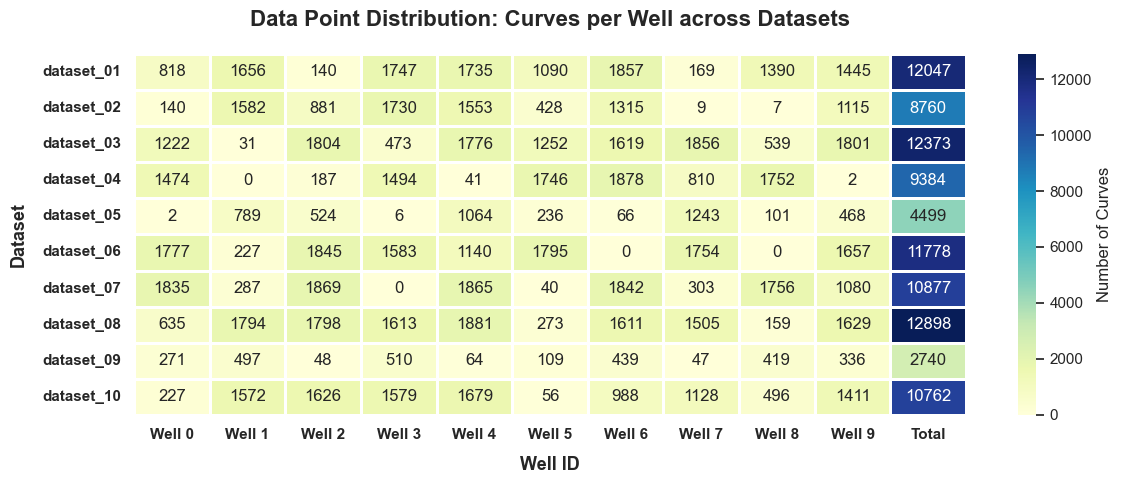

In [67]:
visualize_well_data_distribution()

In [68]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

import config

# ====================================================================
# CONFIGURATIONS
# ====================================================================
# These must perfectly match the column names in your kinetic_features dataframe
TARGET_FILTERS = [
    'msc_label_msc_linear_0.001',
    'amf_label_amf_important',
    'cnn_ae_glb_ds1_label_elbow',
    'lstm_ae_glb_ds1_label_elbow'
]

FILTER_DISPLAY_NAMES = {
    'None': 'Baseline (0%)',
    'msc_label_msc_linear_0.001': 'MSC',
    'amf_label_amf_important': 'AMF',
    'cnn_ae_glb_ds1_label_elbow': 'CNN AutoEncoder',
    'lstm_ae_glb_ds1_label_elbow': 'LSTM AutoEncoder'
}

# ====================================================================
# DATA EXTRACTION DIRECTLY FROM FEATURES DATAFRAME
# ====================================================================
def parse_features_outlier_data(train_data_path, exp_name):
    """
    Loads the pipeline state, accesses the kinetic_features dataframe, 
    and calculates the percentage of -1 (outliers) for each filter column.
    """
    records = []
    try:
        pipeline_state = joblib.load(train_data_path)
        
        # Locate the original curves dataframe
        ori_idx = list(pipeline_state["dataset_name"]).index("ori_curves")
        features_df = pipeline_state["kinetic_features"][ori_idx]
        
    except Exception as e:
        print(f"  [!] Failed to load or parse dataframe in {exp_name}: {e}")
        return records

    total_curves = len(features_df)
    
    if total_curves == 0:
        return records

    # 1. Add the Baseline (0% outliers by definition)
    records.append({
        'Experiment': exp_name,
        'Filter': 'None',
        'Outlier_Percentage': 0.0
    })

    # 2. Calculate percentage of -1 labels for each target filter
    for filter_col in TARGET_FILTERS:
        if filter_col in features_df.columns:
            # Count how many labels are exactly -1
            outlier_count = (features_df[filter_col] == -1).sum()
            outlier_pct = outlier_count / total_curves
            
            records.append({
                'Experiment': exp_name,
                'Filter': filter_col,
                'Outlier_Percentage': float(outlier_pct)
            })
        else:
            print(f"    [-] Missing column '{filter_col}' in {exp_name}")
            
    return records

# ====================================================================
# HEATMAP ENGINE
# ====================================================================
def generate_outlier_heatmap(df, save_path):
    sns.set_theme(style="white")
    
    df_masked = df.copy()
    
    # Mask real experiment names to 'dataset_01', 'dataset_02'
    unique_exps = df_masked['Experiment'].unique()
    exp_mapping = {exp: f"dataset_{i+1:02d}" for i, exp in enumerate(unique_exps)}
    df_masked['Experiment'] = df_masked['Experiment'].map(exp_mapping)

    # Pivot: Rows=Dataset, Cols=Filter
    pivot_df = df_masked.pivot(index='Experiment', columns='Filter', values='Outlier_Percentage')
    
    # Reorder columns to ensure 'None' is first, followed by the specific filters
    display_order = ['None'] + TARGET_FILTERS
    existing_filters = [f for f in display_order if f in pivot_df.columns]
    pivot_df = pivot_df[existing_filters]
    
    # Clean up the display names
    pivot_df.rename(columns=FILTER_DISPLAY_NAMES, inplace=True)

    # Setup Figure Size dynamically
    fig, ax = plt.subplots(figsize=(10, max(5, len(unique_exps) * 0.5)))

    # Plot Heatmap using "Reds"
    sns.heatmap(
        pivot_df, 
        annot=True,               
        fmt=".1%",                # Format as percentage (e.g., 5.2%)
        cmap="Reds",              
        vmin=0.0,                 
        vmax=pivot_df.max().max(),# Scale safely to the highest drop rate
        linewidths=0.5,
        linecolor='lightgray',
        ax=ax,
        cbar_kws={'label': '% of Data Flagged as Outliers (-1)'}
    )
    
    # Formatting
    ax.set_title("Outlier Rejection Rate by Filter across Datasets", fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel("Outlier Filter Strategy", fontsize=13, fontweight='bold', labelpad=15)
    ax.set_ylabel("Dataset", fontsize=13, fontweight='bold', labelpad=10)
    
    # Rotate X-axis labels to prevent text overlap
    ax.tick_params(axis='x', rotation=45)
    for tick in ax.get_xticklabels():
        tick.set_ha('right')
        tick.set_fontweight('bold')
        
    for tick in ax.get_yticklabels():
        tick.set_fontweight('bold')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)

# ====================================================================
# ORCHESTRATOR
# ====================================================================
def plot_outlier_distributions(exp_folder=config.DEFAULT_EXP_FOLDER):
    print(f"[*] Scanning {exp_folder} for outlier data in kinetic features...")
    
    exp_paths = sorted([
        Path(exp_folder, name) for name in os.listdir(exp_folder) 
        if os.path.isdir(os.path.join(exp_folder, name)) and name != ".DS_Store"
    ])

    all_results = []

    for exp_path in exp_paths:
        train_data_path = os.path.join(exp_path, config.TRAINING_DATA_PATH)
        if not os.path.exists(train_data_path):
            continue
            
        print(f"  -> Processing: {exp_path.name}")
        parsed_data = parse_features_outlier_data(train_data_path, exp_path.name)
        all_results.extend(parsed_data)

    if not all_results:
        print("[!] No valid outlier data found in any pipeline state.")
        return

    df = pd.DataFrame(all_results)
    
    save_path = os.path.join(exp_folder, "global_outlier_percentage_heatmap.png")
    print(f"\n[*] Generating Outlier Percentage Heatmap...")
    generate_outlier_heatmap(df, save_path)
    
    print(f"[✓] Saved chart to: {save_path}")

if __name__ == "__main__":
    plot_outlier_distributions()

[*] Scanning /vol/bitbucket/gk225/POC_DDM_dataset for outlier data in kinetic features...
  -> Processing: D20250808_E00_C00_F4500KHz_U_Sample_7
  -> Processing: D20250811_E00_C00_F4500KHz_U_Sample_6
  -> Processing: D20250812_E00_C00_F4500KHz_U_Sample_2_Rep2
  -> Processing: D20250815_E00_C00_F4500KHz_U_Sample_11_rep2
  -> Processing: D20250818_E00_C00_F4500KHz_U_Sample_13
  -> Processing: D20250818_E00_C00_F4500KHz_U_Sample_15
  -> Processing: D20250818_E00_C00_F4500KHz_U_Sample_17
  -> Processing: D20250820_E00_C00_F4500KHz_U_Sample_18_wet_3
  -> Processing: D20250826_E00_C00_F4500KHz_U_Sample_14_rep2
  -> Processing: D20250828_E00_C00_F4500KHz_U_Sample_mix_3

[*] Generating Outlier Percentage Heatmap...
[✓] Saved chart to: /vol/bitbucket/gk225/POC_DDM_dataset/global_outlier_percentage_heatmap.png


# PLAYGROUND

In [25]:
TRAINING_DATA_PATH = 'curve_for_training.joblib'

training_data_path = os.path.join(config.DEFAULT_EXP_FOLDER, "dataset_01", TRAINING_DATA_PATH)

In [26]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import FuncFormatter

import config
%matplotlib inline

exp_folder=config.DEFAULT_EXP_FOLDER
exp_paths = sorted([
    Path(exp_folder, name) for name in os.listdir(exp_folder) 
    if os.path.isdir(os.path.join(exp_folder, name)) and name != ".DS_Store"
])


In [33]:
KFS = ['Fm', 'Fb', 'Sc', 'Cs', 'As', 'xms', 'xs', 'xe', 'xp1', 'xp2', 'TH', 'y_xms', 'y_xs', 'y_xe', 'y_xp1', 'y_xp2', 'amplitude', 'dy_xms', 'dy_xp1', 'dy_xp2', 'd2y_xp1', 'd2y_xp2', 'threshold_distance', 'first_half_distance', 'second_half_distance', 'distance_asymmetry_index', 'peak_shifting_distance', 'A1', 'A2', 'area_asymmetry_index', 'peak_asymmetry_index', 'Ct', 'Cy0', 'F_max', 'log_F0', 'F0', 'Send', 'FFI', 'F_range']
exp_path = exp_paths[0]
sample_data = joblib.load(Path(exp_path, config.TRAINING_DATA_PATH))
dataset_name = sample_data['dataset_name'][0]
dataset = sample_data['dataset'][0]
kinetic_feature_df = sample_data['kinetic_features'][0][KFS]
metadata_df = sample_data['metadata_df']
Y_well = sample_data['Y_well']
timestamps = sample_data['timestamps']

In [32]:
sample_data["dataset"][0].shape

(12047, 615)

In [29]:
sample_data['metadata_df']

,pixel_row_idx,pixel_col_idx,temp_group_idx,num_active_pixels_in_temp_group,well_temp_lin2d_mean,well_2d_temp_npr_mean
0,14,22,46,3,NaN,6.129231
1,14,23,46,3,NaN,6.129231
2,14,24,46,3,NaN,6.129231
3,14,25,47,5,NaN,6.544615
4,14,26,47,5,NaN,6.544615
...,...,...,...,...,...,...
12042,48,76,195,18,NaN,6.004615
12043,48,77,195,18,NaN,6.004615
12044,48,78,195,18,NaN,6.004615
12045,48,79,195,18,NaN,6.004615


In [28]:
sample_data.keys()

dict_keys(['dataset_name', 'dataset', 'Y_well', 'timestamps', 'metadata_df', 'kinetic_features', 'linear_feature_combinations', 'important_feature_combinations', 'importance_dfs'])

import curve
reshape (X, Y_well, timestamp)
sigmoid fit
extract features

model comparison (cnn, gru, lstm), no outlier settings
compare cnn with paper
late fusion
dual model


In [34]:
sample_prep = joblib.load(Path(exp_path, config.PREPROCESSED_CURVES_PATH))


In [37]:
sample_prep.keys()

dict_keys(['curves', 'sigmoid_curves', 'idxs', 'timestamps', 'well_labels', 'metadata', 'baseline_value', 'window_size_1stder', 'margin'])

In [40]:
sample_prep['curves'].keys()

dict_keys(['well_2d_bs_active', 'well_2d_nl_bs_active', 'well_temp_lin2d', 'well_2d_temp_npr', 'well_temp_mean_then_lin', 'ori_curves', 'ori_curve_dydx', 'ori_dydx_avg', 'cleaned_std', 'cleaned_lowest'])

In [61]:
sample_prep['sigmoid_curves'].keys()

dict_keys(['original', 'cleaned_std', 'cleaned_lowest'])

In [62]:
sample_prep['sigmoid_curves']['original'].keys()

dict_keys(['fitted_full', 'fitted_stretched', 'params', 'rmse'])

In [42]:
sample_prep['idxs'].keys()

dict_keys(['idx_start', 'idx_settled', 'idx_end', 'idx_active', 'cleaned_idx', 'cleaned_lowest_idx'])

In [45]:
sample_prep['timestamps'].shape

(615,)

In [49]:
sample_prep['well_labels'].shape

(12047,)

In [58]:
sample_prep['metadata'].keys()

dict_keys(['pixel_row_idx', 'pixel_col_idx', 'temp_group_idx', 'num_active_pixels_in_temp_group', 'well_temp_lin2d_mean', 'well_2d_temp_npr_mean'])

In [56]:
sample_prep['margin']

99

In [63]:
sample_data

{'dataset_name': array(['ori_curves', 'original_fitted_full', 'original_fitted_stretched',
        'cleaned_std_fitted_full', 'cleaned_std_fitted_stretched',
        'cleaned_lowest_fitted_full', 'cleaned_lowest_fitted_stretched'],
       dtype='<U31'),
 'dataset': array([[[0.21988262, 0.22558095, 0.2210319 , ..., 0.23737259,
          0.23833428, 0.23342296],
         [0.21988262, 0.2258958 , 0.22294841, ..., 0.22549859,
          0.22392282, 0.2264941 ],
         [0.21988262, 0.21528325, 0.21852212, ..., 0.22225283,
          0.22125932, 0.22345642],
         ...,
         [0.21988262, 0.21351777, 0.20899276, ..., 0.22880157,
          0.23097588, 0.22826518],
         [0.21988262, 0.22144884, 0.22014197, ..., 0.24324772,
          0.24406784, 0.24439776],
         [0.21988262, 0.2206309 , 0.2206309 , ..., 0.25205943,
          0.24702318, 0.24915527]],
 
        [[0.21967636, 0.21967636, 0.21967636, ..., 0.23280576,
          0.23280652, 0.23280726],
         [0.20999461, 0.20999461